# Notebook 13 - Solving Differential Equations Numerically


In [1]:
import sympy as sy
sy.init_printing() # display better looking symbols in Jupyter notebooks
import numpy as np
import matplotlib.pyplot as plt


## Part 1 - Euler's Method

Initial goal: Solve first-order one-variable ordinary differential equations (given an initial condition). These equations will take the form:

$\frac{dx}{dt}=f(x,t)$

For example, we could consider the case of linear drag where we have a velocity dependent force ($F_{\text{drag}} = -bv$, where $b$ is a constant):

$\sum F=ma$

$-bv(t)=m\frac{dv}{dt}$

$\frac{dv}{dt}=-\frac{b}{m}v(t)$

To solve an equation such as $\frac{dx}{dt}=f(x,t)$ numerically, we can first taylor expand $x(t)$ about a given point $t_0$, then evaluate the function some short time $\Delta t$ later:

$x(t)|_{t_0} = x(t_0)+\frac{(t-t_0)}{1!}\frac{d}{dt}x(t_0)+\frac{(t-t_0)^2}{2!}\frac{d^2}{dt^2}x(t_0)+...$


$x(t_0+\Delta t) = x(t_0)+\frac{((t_0+\Delta t)-t_0)}{1!}\frac{d}{dt}x(t_0)+\frac{((t_0+\Delta t)-t_0)^2}{2!}\frac{d^2}{dt^2}x(t_0)+...$

$x(t_0+\Delta t) = x(t_0)+\Delta t\frac{d}{dt}x(t_0)+\frac{1}{2}(\Delta t)^2\frac{d^2}{dt^2}x(t_0)+...$

Note our original differential equation is of the form $\frac{dx}{dt}=f(x,t)$. Plugging this in for $\frac{dx}{dt}$ we have:

$x(t_0+\Delta t) = x(t_0)+\Delta t f(x,t)+\mathcal{O}[(\Delta t)^2]+...$

If we neglect terms of order $(\Delta t)^2$, we then have ***Euler's method***:

$x(t_0+\Delta t) = x(t_0)+\Delta t f(x,t)$

That is, if we know the initial condition $x(t_0)$, we can estimate the value of x one small time step later $x(t_0+\Delta t)$ using the fact that we know the slope at $x(t_0)$ (since the differential equation tells us the slope: $\frac{dx}{dt}=f(x,t)$). We can repeat this after each time step to estimate the value one time step later.

#### Example: Velocity dependent force

One quick example: $\frac{dv}{dt}=-\frac{b}{m}v(t)$

We know the initial velocity is 10 m/s. $b=1$, $m=1$. We can estimate the value of the velocity after a few small time steps using Euler's method:


| t (s)    | v (m/s)   |
|:---:  |:---:|
| 0     | 10  |
| 0.1     | 10 - 0.1*10 =  9   |
| 0.2     | 9 - 0.1*9 =  8.1   |
| 0.3     | 8.1 - 0.1*8.1 =  7.29   |
| 0.4     | 7.29 - 0.1*8.1 =  6.561    |


#### Example: Newton's law of cooling

Let's code up an example using Newton's Law of Cooling:

$\frac{dT}{dt} = - k (T(t) - T_\text{env})$

Here k is a constant $k = \frac{hA}{mc}$ where $m$ is the mass, $c$ is the heat capacity, $h$ is the heat transfer coefficient, and $A$ is the surface area.

This equation shows us that the rate of cooling depends on the temperature difference between the object and the environment.

delta_t 3.75


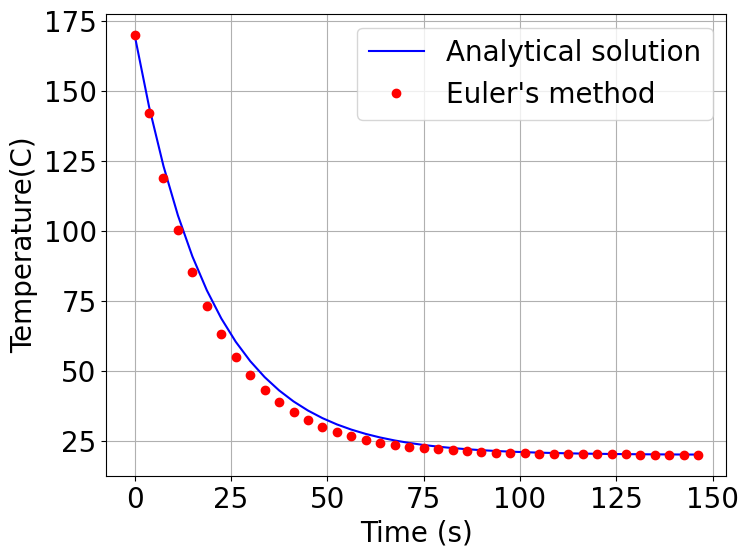

In [2]:
# Perform the Euler method to numerical solve a differential equation (Newton's heat equation)
#    given some starting condition

# Function which finds the slope
#  for a given time and temperature
def f_diffeq_rhs(t,k,T_env,T):
    myf = -k * ( T - T_env )
    #print(t, T, myf)
    return myf

# Function which evaluates the analytical solution
#  for a given time
def f_ana(t,k,T_env,T_0):
    analytical_f = T_env + ( T_0 - T_env )*np.exp(-k*t)
    return analytical_f


# Set time range (minutes)
a = 0.0
b = 150.0

# Set number of time divisions and step size delta_t
N = 40
delta_t = (b-a)/N
print("delta_t",delta_t)

# Define the initital temperature, the environment temperature, and the constant
T_0 = 170  # C
T_env = 20 # C
k = 0.05 # /min

# Array of time
tpoints  = np.arange(a,b,delta_t)

# Empty lists to store temperature
Tpoints_euler  = []
Tpoints_ana    = []

# Start the process at t=0
Temp = T_0

for t in tpoints:

    # put the temperatures for this time
    #  iteration into the array
    Tpoints_euler.append(Temp)
    Tpoints_ana.append( f_ana(t,k,T_env,T_0) )

    # Use the current time and temperature
    #  and the differential equation to find the slope
    #  at this time then perform euler's method
    #  to find the temp for the next iteration
    Temp += delta_t*f_diffeq_rhs(t,k,T_env,Temp)


plt.figure(figsize=(8,6))

plt.plot(tpoints,Tpoints_ana, "b" , label='Analytical solution')
plt.plot(tpoints,Tpoints_euler, "ro" , label="Euler's method")

plt.xlabel("Time (s)" , fontsize=20)
plt.ylabel("Temperature(C)" , fontsize=20)

plt.legend(loc='upper right', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)

plt.show()

Caution: In some situations a numerical solution for a differential equation can become unstable. Some differential equations more more susceptible to this. These are known as stiff differential equations. Alternative methods can be used if this is a problem.

delta_t 50.0


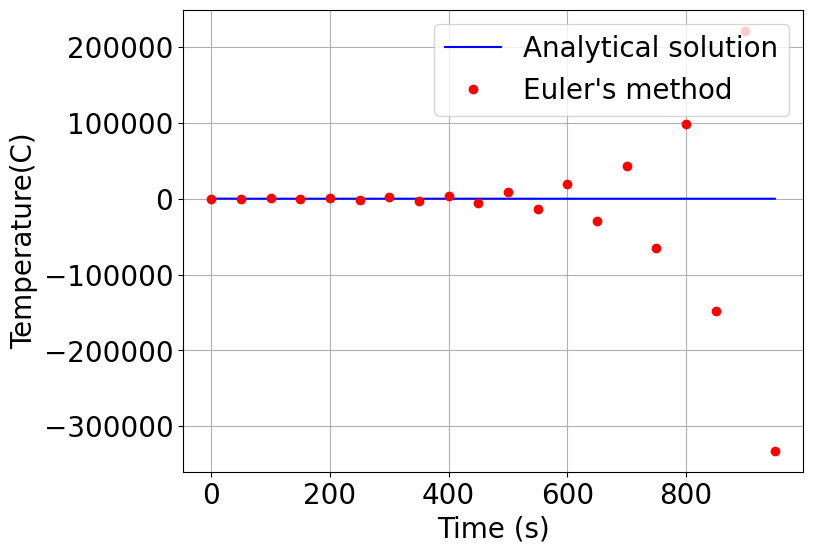

In [3]:
# Perform the Euler method to numerical solve a differential equation (Newton's heat equation)
#    given some starting condition

# Function which finds the slope
#  for a given time and temperature
def f_diffeq_rhs(t,k,T_env,T):
    myf = -k * ( T - T_env )
    #print(t, T, myf)
    return myf

# Function which evaluates the analytical solution
#  for a given time
def f_ana(t,k,T_env,T_0):
    analytical_f = T_env + ( T_0 - T_env )*np.exp(-k*t)
    return analytical_f


# Set time range (minutes)
a = 0.0
b = 1000.0

# Set number of time divisions and step size delta_t
N = 20
delta_t = (b-a)/N
print("delta_t",delta_t)

# Define the initital temperature, the environment temperature, and the constant
T_0 = 170  # C
T_env = 20 # C
k = 0.05 # /min

# Array of time
tpoints_2  = np.arange(a,b,delta_t)

# Empty lists to store temperature
Tpoints_euler_2  = []
Tpoints_ana_2    = []

# Start the process at t=0
Temp = T_0

for t in tpoints_2:

    # put the temperatures for this time
    #  iteration into the array
    Tpoints_euler_2.append(Temp)
    Tpoints_ana_2.append( f_ana(t,k,T_env,T_0) )

    # Use the current time and temperature
    #  and the differential equation to find the slope
    #  at this time then perform euler's method
    #  to find the temp for the next iteration
    Temp += delta_t*f_diffeq_rhs(t,k,T_env,Temp)


plt.figure(figsize=(8,6))

plt.plot(tpoints_2,Tpoints_ana_2, "b" , label='Analytical solution')
plt.plot(tpoints_2,Tpoints_euler_2, "ro" , label="Euler's method")

plt.xlabel("Time (s)" , fontsize=20)
plt.ylabel("Temperature(C)" , fontsize=20)

plt.legend(loc='upper right', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)

plt.show()

## Part 2 - Solving Differential equaitons using built in tools

The scipy (scientific python) library includes multiple tools to solve ordinary diffential equation (ode) "initial value problems (ivp)". For example: scipy.integrate.odeint

Other languages have similar tools (C++ has odeint, matlab has dsolve, FORTRAN has odepack)

#### odeint
https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.odeint.html

scipy.integrate.odeint(func, y0, t, args=(), Dfun=None, col_deriv=0, full_output=0, ml=None, mu=None, rtol=None, atol=None, tcrit=None, h0=0.0, hmax=0.0, hmin=0.0, ixpr=0, mxstep=0, mxhnil=0, mxordn=12, mxords=5, printmessg=0, tfirst=False)

Here func is the function, y0 is the initial value, and t is the time array over which you would like to solve, and args is a tuple containing the value of constants.

delta_t 3.75


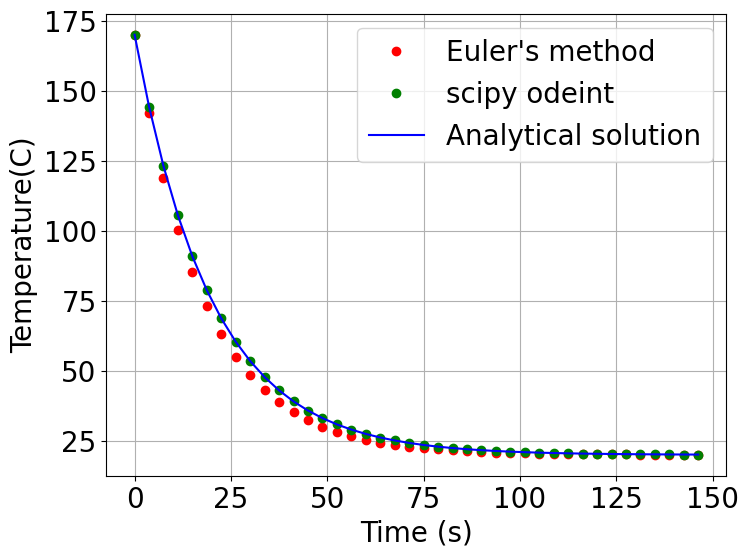

In [4]:
from scipy.integrate import odeint

############
# Define and solve the diffEQ

def f(T,t,k,T_env):
    myf = -k * ( T - T_env )
    return myf

# Define the initital temperature, the environment temperature, and the constant
T_0 = 170  # C
T_env = 20 # C
k = 0.05 # /min

# Set time range (minutes)
a = 0.0
b = 150.0

# Set number of time divisions and step size delta_t
N = 40
delta_t = (b-a)/N
print("delta_t",delta_t)

# Array of time
tpoints  = np.arange(a,b,delta_t)

# Solve
soln = odeint(f, T_0, tpoints, args=(k, T_env)) # returns an array of arrays, each containing the values for each function (in this case we only have the temperature function)
Tpoints_odeint = soln[:, 0]
#print(Tpoints_odeint)

############
# Make plots

plt.figure(figsize=(8,6))

plt.plot(tpoints,Tpoints_euler, "ro" , label="Euler's method")
plt.plot(tpoints,Tpoints_odeint, "go" , label="scipy odeint")
plt.plot(tpoints,Tpoints_ana, "b" , label='Analytical solution')

plt.xlabel("Time (s)" , fontsize=20)
plt.ylabel("Temperature(C)" , fontsize=20)

plt.legend(loc='upper right', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)

plt.show()


It is also possible to use a computer to find the analytical solution to a diffential equation (if possible).

Sympy is a python library for symbolic math (it is like a free Mathematica)

In [5]:
import sympy as sy
sy.init_printing() # display better looking symbols in Jupyter notebooks

In [6]:
t, T_0, T_env, k = sy.symbols("t, T_{0}, T_{env}, k")
T = sy.Function("T")

In [7]:
T(t)

T(t)

In [8]:
ode = sy.Derivative( T(t) , t ) + k*(T(t)-T_env)

In [9]:
sy.Eq(ode,0)

                      d           
k⋅(-T_{env} + T(t)) + ──(T(t)) = 0
                      dt          

In [10]:
solution = sy.dsolve(ode)

In [11]:
solution

           -k⋅t          
T(t) = C₁⋅ℯ     + T_{env}

In [12]:
solution.lhs

T(t)

In [13]:
solution.rhs

    -k⋅t          
C₁⋅ℯ     + T_{env}

In [14]:
sy.Eq( solution.lhs  , solution.rhs  )

           -k⋅t          
T(t) = C₁⋅ℯ     + T_{env}

In [15]:
sy.Eq( solution.lhs - solution.rhs ,0  )

      -k⋅t                     
- C₁⋅ℯ     - T_{env} + T(t) = 0

In [16]:
sy.Eq( solution.lhs.subs(t,0) -  solution.rhs.subs(t,0),0 )

-C₁ - T_{env} + T(0) = 0

In [17]:
C1 = sy.solve(  sy.Eq( solution.lhs.subs(t,0) -  solution.rhs.subs(t,0),0 ) )
C1

[{C₁: -T_{env} + T(0)}]

In [18]:
solution.subs(C1[0])


                                    -k⋅t
T(t) = T_{env} + (-T_{env} + T(0))⋅ℯ    

## Part 3 - Solving Simultaneous Differential Equations

In [19]:
# Define functions to solve simultaneous differential equations

# ------------------------------------------------------------------------
# Estimate the solution to a differential equation using Euler's method
def run_euler_vec(a,b,N,r_initial):

    delta_t = (b-a)/N  # find the step size delta_t
    r = r_initial      # Set the initial condition (r is a 1D numpy array (a vector))
    time_array  = np.arange(a,b,delta_t)  # array for iteration
    print("Run Euler: delta_t = ",delta_t, " r_initial = ",r_initial)

    # lists to track x and t for each step
    tpoints  = []
    xpoints  = []
    ypoints  = []

    # loop over the time range with step size delta_t
    for t in time_array:
        #print("x=",r[0],"y=",r[1],"[dx/dt,dy/dt]=",f(r,t))
        xpoints.append(r[0]) # put the values for this time into the array
        ypoints.append(r[1]) # put the values for this time into the array
        tpoints.append(t) # keep track of the time for plotting
        #  perform euler's method (setup the values for the next time iteration)
        r += delta_t * f(r,t)

    return xpoints, ypoints, tpoints

In [20]:
# ------------------------------------------------------------------------
# define two simultaneous ode
# dr/dt = f(r,t)
def f(r,t):
    x = r[0]
    y = r[1]
    fx = x*y - x
    fy = y - x*y + np.sin(t)**2
    return np.array([fx,fy],float)

# ------------------------------------------------------------------------

# Set time range a->b (seconds), the number of steps N, and the initial ocndition
a = 0.0
b = 10.0
N = 100
r_initial = np.array([1.0,1.0],float)

# Run the euler method
eu_ex85_x, eu_ex85_y, eu_ex85_t = run_euler_vec(a, b, N, r_initial)


Run Euler: delta_t =  0.1  r_initial =  [1. 1.]


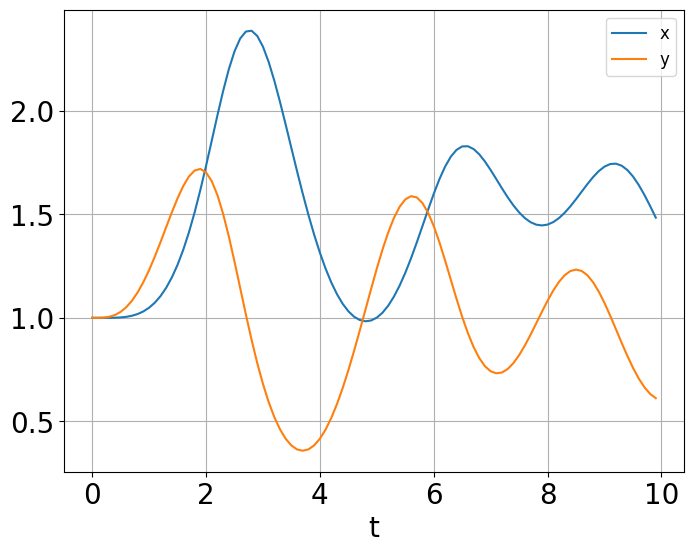

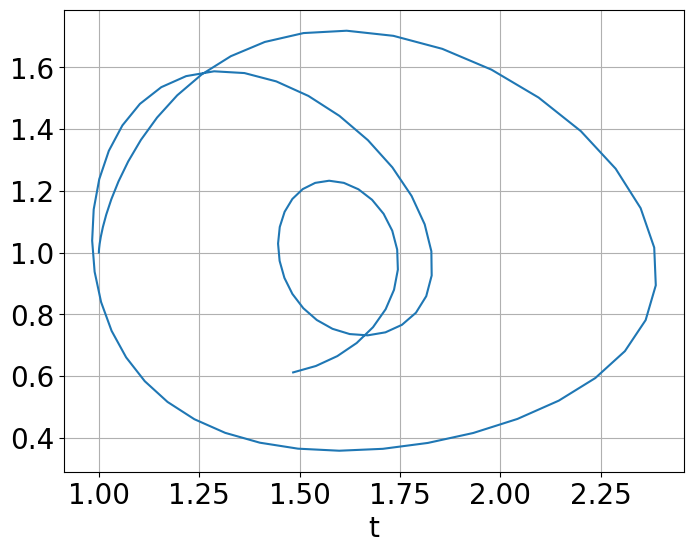

In [21]:
plt.figure(figsize=(8,6))
plt.plot(eu_ex85_t,eu_ex85_x, "-" , label="x")
plt.plot(eu_ex85_t,eu_ex85_y, "-" , label="y")
plt.xlabel("t" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.plot(eu_ex85_x,eu_ex85_y, "-")
plt.xlabel("t" , fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.show()

Run Euler: delta_t =  0.03  r_initial =  [1. 1.]


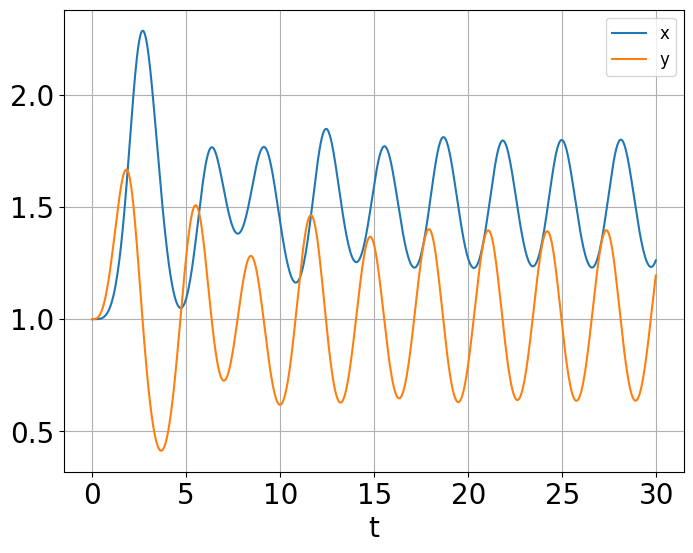

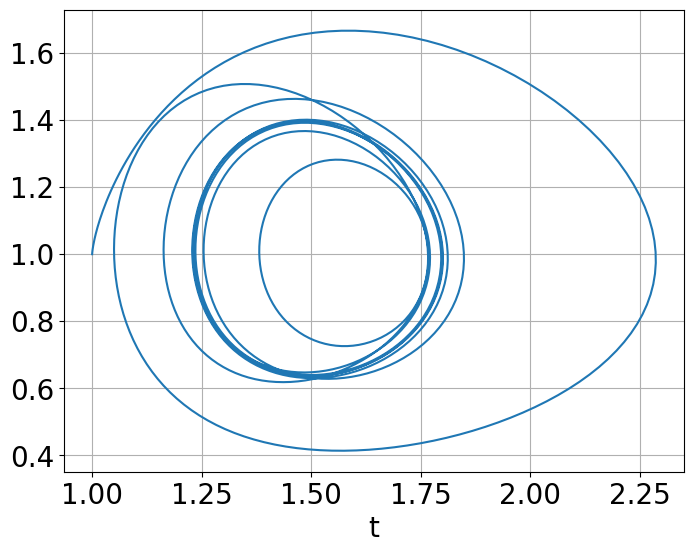

In [22]:
# Set time range a->b (seconds), the number of steps N, and the initial ocndition
a = 0.0
b = 30.0
N = 1000
r_initial = np.array([1.0,1.0],float)

# Run the euler method
eu_ex85_x, eu_ex85_y, eu_ex85_t = run_euler_vec(a, b, N, r_initial)


plt.figure(figsize=(8,6))
plt.plot(eu_ex85_t,eu_ex85_x, "-" , label="x")
plt.plot(eu_ex85_t,eu_ex85_y, "-" , label="y")
plt.xlabel("t" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.plot(eu_ex85_x,eu_ex85_y, "-")
plt.xlabel("t" , fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.show()

### Simultaneous ODEs with built-in tools

Example:

"predator-prey equations" ("Lotka-Volterra")


Prey follow the equation:

$du/dt = au - buv$

Predator follow the equation:

$dv/dt = -cv + duv$


with the following notations:

    u: number of preys (for example, cattle)

    v: number of predators (for example, aliens)

    a, b, c, d are constant parameters defining the behavior of the population:

        a is the natural growing rate of cattle, when there's no aliens

        b is the natural dying rate of cattle, due to predation

        c is the natural dying rate of aliens, when there's no cattle

        d is the factor describing how many caught cattle help create a new alien


Prey have an unlimited food supply and reproduce exponentially (this comes from $du/dt = au$)

Prey die at a rate proportional to the rate at which they meet pretators ($du/dt = - buv$)


Predators reproduce exponentially if food is available. The rate is proportional to the ammount of food ($dv/dt = duv$)

Predators die without food ($dv/dt = -cv$)

In [23]:
# Cows vs Aliens. Predator prey
# Code based on:
# http://scipy-cookbook.readthedocs.io/items/LoktaVolterraTutorial.html

from numpy import *
import pylab as p
from scipy import integrate

# Definition of parameters
a = 1.   #  a growing rate of cattle, when there's no aliens
b = 0.1  #  b dying rate of cattle, due to predation
c = 1.5  #  c dying rate of aliens, when there's no cattle
d = 0.75 #  d factor describing how many caught cattle let create a new alien

def dX_dt(X, t=0):
    """ Return the growth rate of alien and cattle populations. """
    return array([ a*X[0] -   b*X[0]*X[1] ,
                  -c*X[1] + d*b*X[0]*X[1] ])

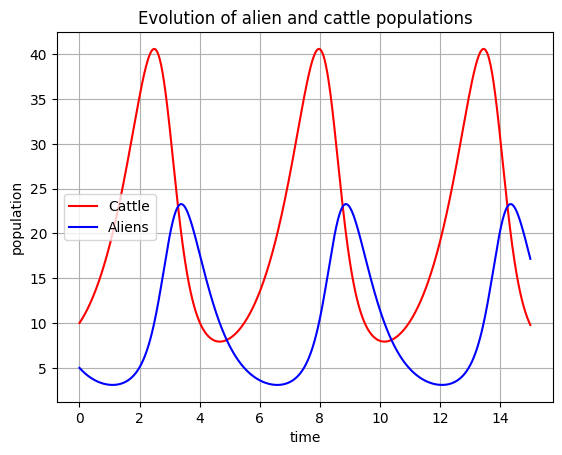

In [24]:
t = linspace(0, 15,  1000)              # time
X0 = array([10, 5])                     # initials conditions: 10 cattle and 5 aliens
X = integrate.odeint(dX_dt, X0, t)

cattle = X[:, 0]
aliens = X[:, 1]

f1 = p.figure()
p.plot(t, cattle, 'r-', label='Cattle')
p.plot(t, aliens  , 'b-', label='Aliens')
p.grid()
p.legend(loc='best')
p.xlabel('time')
p.ylabel('population')
p.title('Evolution of alien and cattle populations')
p.show()

## The Runge-Kutta set of methods

Goal: Solve differential equation of the form $\frac{dx}{dt}=f(x(t),t)$

Recall: Euler's method dropped terms of the order $\frac{1}{2}(\Delta t)^2\frac{d^2 x}{dt^2}=\frac{1}{2}(\Delta t)^2\frac{d f}{dt}$

We could add these terms to improve accuracy but we often don't know $\frac{d f}{dt}$

The Runge-Kutta (RK) set of methods can provide more accuracy without requiring us to solve any derivatives with only a moderate increase in algorithm complexity.

- First order Runge-Kutta method = "RK1" = "Euler's method"
- Second order Runge-Kutta method = "RK2" = "Midpoint method"
- Fourth order Runge-Kutta method = "RK4"

Euler's method uses the slope at time $t$ to estimate the value of $x(t)$ at time $t+\Delta t$

The ***midpoint method*** or ***RK2*** uses the slope at the midpoint instead $\frac{dx (t+\frac{1}{2}\Delta t)}{dt}$. This provides a much better approximation. Unforuntately we don't know the value of the function at the midpoint $x(t+\frac{1}{2}\Delta t)$. We can then use Euler's method to estimate this, then use the slope at the midpoint to estimate the next value of the function.

The ***RK4*** method uses a similar method to improve the accuracy. Perform a taylor expansion around multiple points and find linear combinations of these taylor expansions such that terms of order $(\Delta t)^2$, $(\Delta t)^3$ etc. are canceled.



#### Midpoint or "RK2" method

For a general differential equation of the form $\frac{dx}{dt}=f(x,t)$

$k_1 = \Delta t~f(x(t),t)$

$k_2 = \Delta t~f(x(t)+ \frac{1}{2} k_1, t+\frac{1}{2}\Delta t)$

$x(t+\Delta t) = x(t) + k_2$

This method is accurate to $(\Delta t)^2$ (errors of order $(\Delta t)^3$ for a single step)

Euler's method is accurate to $(\Delta t)$ (errors of order $(\Delta t)^2$ for a single step)



#### The 4th order Runge-Kutta Method "RK4"

$k_1 = \Delta t~f(x(t),t)$

$k_2 = \Delta t~f(x(t)+ \frac{1}{2} k_1, t+\frac{1}{2}\Delta t)$

$k_3 = \Delta t~f(x(t)+ \frac{1}{2} k_2, t+\frac{1}{2}\Delta t)$

$k_4 = \Delta t~f(x(t)+ k_3, t+\Delta t)$

$x(t+\Delta t) = x(t) + \frac{1}{6}(k_1+2k_2+2k_3+k_4)$

#### Exercise:

Below I've copied and pasted the Euler's method example from above.

Modify this code to include the Midpoint method (RK2).

delta_t 3.75


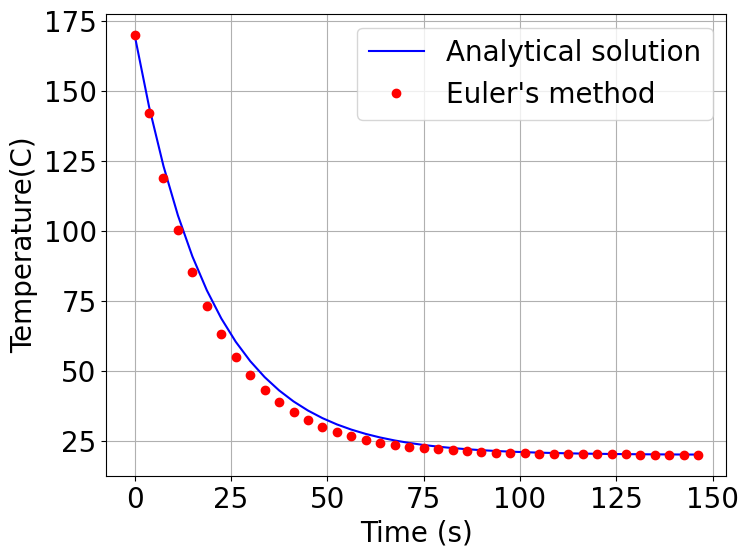

In [25]:
# Perform the Euler method to numerical solve a differential equation (Newton's heat equation)
#    given some starting condition

# Function which finds the slope
#  for a given time and temperature
def f_diffeq_rhs(t,k,T_env,T):
    myf = -k * ( T - T_env )
    #print(t, T, myf)
    return myf

# Function which evaluates the analytical solution
#  for a given time
def f_ana(t,k,T_env,T_0):
    analytical_f = T_env + ( T_0 - T_env )*np.exp(-k*t)
    return analytical_f


# Set time range (minutes)
a = 0.0
b = 150.0

# Set number of time divisions and step size delta_t
N = 40
delta_t = (b-a)/N
print("delta_t",delta_t)

# Define the initital temperature, the environment temperature, and the constant
T_0 = 170  # C
T_env = 20 # C
k = 0.05 # /min

# Array of time
tpoints  = np.arange(a,b,delta_t)

# Empty lists to store temperature
Tpoints_euler  = []
Tpoints_ana    = []

# Start the process at t=0
Temp = T_0

for t in tpoints:

    # put the temperatures for this time
    #  iteration into the array
    Tpoints_euler.append(Temp)
    Tpoints_ana.append( f_ana(t,k,T_env,T_0) )

    # Use the current time and temperature
    #  and the differential equation to find the slope
    #  at this time then perform euler's method
    #  to find the temp for the next iteration
    Temp += delta_t*f_diffeq_rhs(t,k,T_env,Temp)


plt.figure(figsize=(8,6))

plt.plot(tpoints,Tpoints_ana, "b" , label='Analytical solution')
plt.plot(tpoints,Tpoints_euler, "ro" , label="Euler's method")

plt.xlabel("Time (s)" , fontsize=20)
plt.ylabel("Temperature(C)" , fontsize=20)

plt.legend(loc='upper right', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)

plt.show()

#### Solution

delta_t 3.3333333333333335


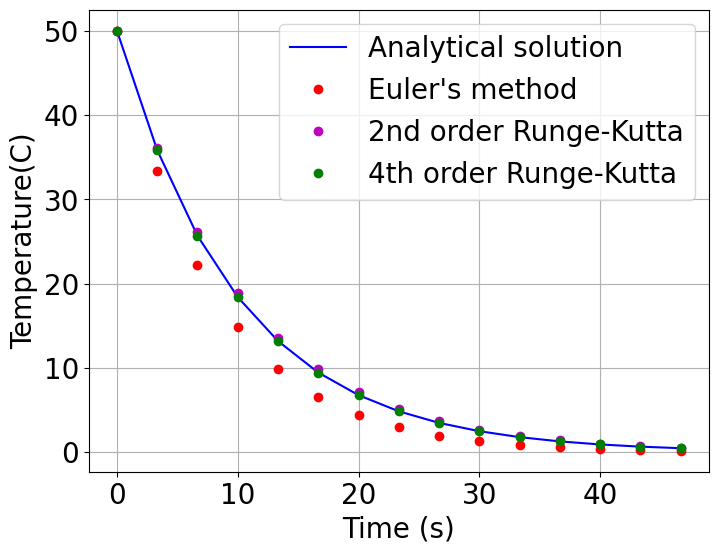

In [26]:
# Perform the 4th order Runge-Kutta (RK) method
#    and the midpoint method (2nd order RK)
#    and the Euler method (1st order RK)
#    to numerically solve a differential equation (Newton's heat equation)
#    given some starting condition

# function to be used for numerical calculation
def f_num(t,T,k,T_env):
    myf = -k * ( T - T_env )
    #print(t, T, myf)
    return myf

# already solved analytical function for comparison
def f_ana(t,k,T_0,T_env):
    analytical_f = T_env + ( T_0 - T_env )*np.exp(-k*t)
    return analytical_f


# Set time range (seconds)
a = 0.0
b = 50.0

# Set number of time divisions and step size delta_t
N = 15
delta_t = (b-a)/N
print("delta_t",delta_t)

# Define the initital temperature, the environment temperature, and the constant
T_0 = 50
T_env = 0
k = 0.1

# Start the process at t=0
Temp1 = T_0
Temp2 = T_0
Temp3 = T_0

tpoints  = np.arange(a,b,delta_t)
Tpoints_eul  = []
Tpoints_rk2  = []
Tpoints_rk4  = []
Tpoints_actual = []

for t in tpoints:

    # put the values for this time into the array
    Tpoints_eul.append(Temp1)
    Tpoints_rk2.append(Temp2)
    Tpoints_rk4.append(Temp3)
    Tpoints_actual.append( f_ana(t,k,T_0,T_env) )

    # setup the values for the next time iteration

    #  perform euler's method
    Temp1 += delta_t*f_num(t,Temp1,k,T_env)

    # perform 2nd order Runge-Kutta method
    k1 = delta_t * f_num( t, Temp2, k , T_env)
    k2 = delta_t * f_num( t+0.5*delta_t, Temp2+0.5*k1, k, T_env)
    Temp2 += k2

    # perform 4th order Runge-Kutta method
    k1 = delta_t * f_num(t,Temp3,k ,T_env)
    k2 = delta_t * f_num(t+0.5*delta_t,Temp3+0.5*k1,k ,T_env)
    k3 = delta_t * f_num(t+0.5*delta_t,Temp3+0.5*k2,k ,T_env)
    k4 = delta_t * f_num(t+delta_t,Temp3+k3,k ,T_env)
    Temp3 += (k1+2*k2+2*k3+k4)/6


plt.figure(figsize=(8,6))

plt.plot(tpoints,Tpoints_actual, "b" , label='Analytical solution')

plt.plot(tpoints,Tpoints_eul, "ro" , label="Euler's method")
plt.plot(tpoints,Tpoints_rk2, "mo" , label="2nd order Runge-Kutta")
plt.plot(tpoints,Tpoints_rk4, "go" , label="4th order Runge-Kutta")

plt.xlabel("Time (s)" , fontsize=20)
plt.ylabel("Temperature(C)" , fontsize=20)

plt.legend(loc='upper right', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)

plt.show()

#### Further examples:

Lets try solving a different differential equation. Lets also generalize our functions for solving using these methods:

$\frac{dx}{dt} =  -x^3 + \sin(t)$

In [27]:
# ------------------------------------------------------------------------
# define ode to be used for testing numerical methods to solve differential equations
# dx/dt = f(x,t)
def f(x,t):
    return -x**3 + np.sin(t)


In [28]:

# ------------------------------------------------------------------------
# Estimate the solution to a differential equation using Euler's method
def run_euler(a,b,N,x_initial):

    delta_t = (b-a)/N  # find the step size delta_t
    x = x_initial      # Set the initial condition
    time_array  = np.arange(a,b,delta_t)  # array for iteration
    print("Run Euler: delta_t = ",delta_t, )

    # lists to track x and t for each step
    tpoints  = []
    xpoints  = []

    # loop over the time range with step size delta_t
    for t in time_array:
        xpoints.append(x) # put the values for this time into the array
        tpoints.append(t) # keep track of the time for plotting
        #  perform euler's method (setup the values for the next time iteration)
        x += delta_t * f(x,t)

    return xpoints, tpoints

# ------------------------------------------------------------------------
# Estimate the solution to a differential equation using the midpoint method (2nd order RK)
def run_rk2(a,b,N,x_initial):

    delta_t = (b-a)/N  # find the step size delta_t
    x = x_initial      # Set the initial condition
    time_array  = np.arange(a,b,delta_t)  # array for iteration
    print("Run RK2: delta_t = ",delta_t)

    # lists to track x and t for each step
    tpoints  = []
    xpoints  = []

    # loop over the time range with step size delta_t
    for t in time_array:
        xpoints.append(x) # put the values for this time into the array
        tpoints.append(t) # keep track of the time for plotting

        # perform 2nd order Runge-Kutta method (setup the values for the next time iteration)
        k1 = delta_t * f( x, t )
        k2 = delta_t * f( x + 0.5*k1 , t + 0.5*delta_t )
        x += k2

    return xpoints, tpoints

# ------------------------------------------------------------------------
# Estimate the solution to a differential equation using the 4th order RK method
def run_rk4(a,b,N,x_initial):

    delta_t = (b-a)/N  # find the step size delta_t
    x = x_initial      # Set the initial condition
    time_array  = np.arange(a,b,delta_t)  # array for iteration
    print("Run RK4: delta_t = ",delta_t)

    # lists to track x and t for each step
    tpoints  = []
    xpoints  = []

    # loop over the time range with step size delta_t
    for t in time_array:
        xpoints.append(x) # put the values for this time into the array
        tpoints.append(t) # keep track of the time for plotting

        # perform 4th order Runge-Kutta method
        k1 = delta_t * f(x, t)
        k2 = delta_t * f(x + 0.5*k1 , t + 0.5*delta_t )
        k3 = delta_t * f(x + 0.5*k2 , t + 0.5*delta_t )
        k4 = delta_t * f(x + k3, t + delta_t)
        x += ( k1 + 2*k2 + 2*k3 + k4 )/6
    return xpoints, tpoints

In [29]:
# ------------------------------------------------------------------------

# Set time range a->b (seconds), the number of steps N, and the initial ocndition
a = 0.0
b = 10.0
x_initial = 0

# Run the euler method
euA_x, euA_t = run_euler(a,b, 10,x_initial)
euB_x, euB_t = run_euler(a,b, 20,x_initial)
euC_x, euC_t = run_euler(a,b, 50,x_initial)

# Run RK2
rk2A_x, rk2A_t = run_rk2(a,b, 10,x_initial)
rk2B_x, rk2B_t = run_rk2(a,b, 20,x_initial)
rk2C_x, rk2C_t = run_rk2(a,b, 50,x_initial)

# Run RK4
rk4A_x, rk4A_t = run_rk4(a,b, 10,x_initial)
rk4B_x, rk4B_t = run_rk4(a,b, 20,x_initial)
rk4C_x, rk4C_t = run_rk4(a,b, 50,x_initial)

Run Euler: delta_t =  1.0
Run Euler: delta_t =  0.5
Run Euler: delta_t =  0.2
Run RK2: delta_t =  1.0
Run RK2: delta_t =  0.5
Run RK2: delta_t =  0.2
Run RK4: delta_t =  1.0
Run RK4: delta_t =  0.5
Run RK4: delta_t =  0.2


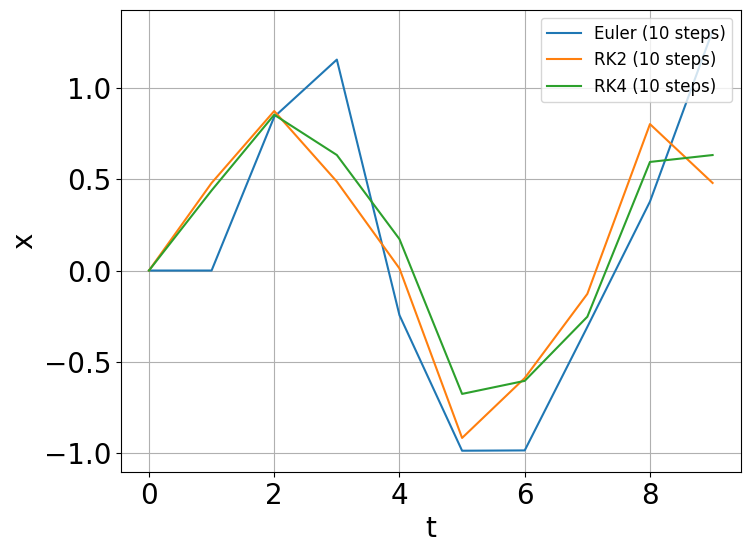

In [30]:

plt.figure(figsize=(8,6))
plt.plot( euA_t, euA_x, "-" , label="Euler (10 steps)")
plt.plot(rk2A_t,rk2A_x, "-" , label="RK2 (10 steps)")
plt.plot(rk4A_t,rk4A_x, "-" , label="RK4 (10 steps)")
plt.xlabel("t" , fontsize=20)
plt.ylabel("x" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.show()


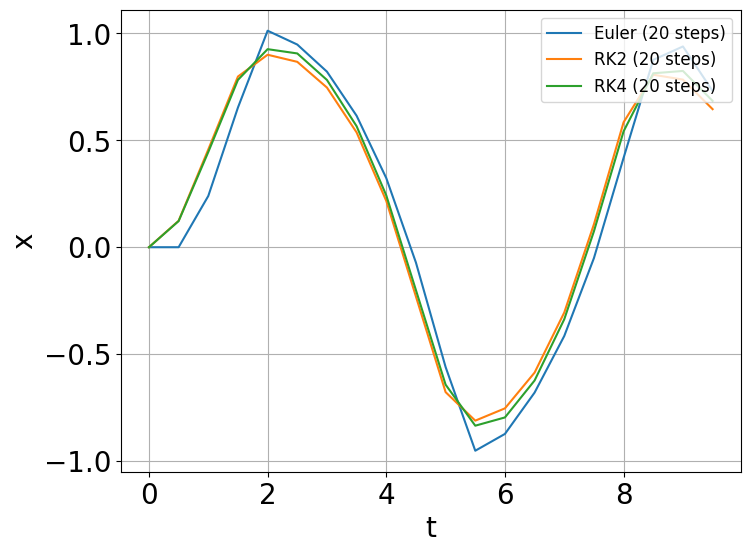

In [31]:
plt.figure(figsize=(8,6))
plt.plot( euB_t, euB_x, "-" , label="Euler (20 steps)")
plt.plot(rk2B_t,rk2B_x, "-" , label="RK2 (20 steps)")
plt.plot(rk4B_t,rk4B_x, "-" , label="RK4 (20 steps)")
plt.xlabel("t" , fontsize=20)
plt.ylabel("x" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.show()


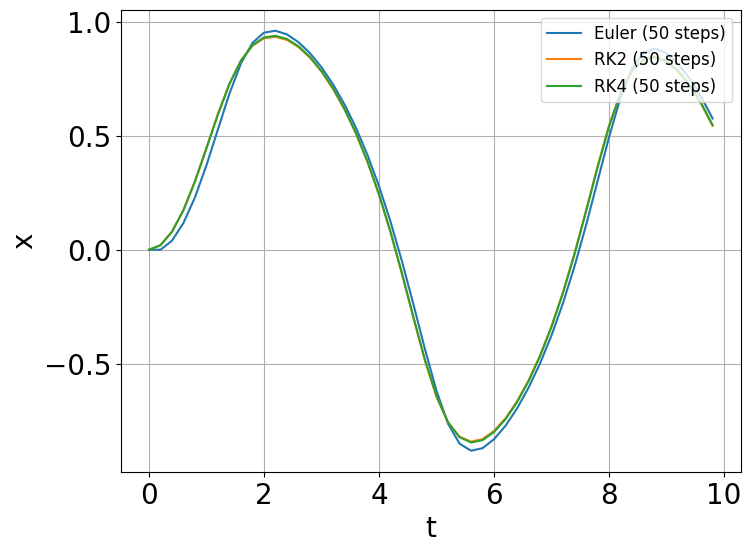

In [32]:

plt.figure(figsize=(8,6))
plt.plot( euC_t, euC_x, "-" , label="Euler (50 steps)")
plt.plot(rk2C_t,rk2C_x, "-" , label="RK2 (50 steps)")
plt.plot(rk4C_t,rk4C_x, "-" , label="RK4 (50 steps)")
plt.xlabel("t" , fontsize=20)
plt.ylabel("x" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.show()

## Solutions over an infinite range

We want to solve a differential equation over an infinite time range

Example: Solve the following differential equation from t=0 to t=$\infty$, given x=1 at t=0.

$\frac{dx}{dt}=\frac{1}{x^2+t^2}$

Generally we want to solve:

$\frac{dx}{dt}=f(x,t)$

Change of variables

$u = \frac{t}{1+t}$

$t = \frac{u}{1-u}$

Chain rule:

$\frac{dx}{du}\frac{du}{dt}=f(x,t)$

$\frac{dx}{du}=\frac{dt}{du}f(x,t)=\frac{dt}{du}f(x,\frac{u}{1-u})$

Plugigng in the derivative of t with respect to u:

$\frac{dx}{du}=\frac{1}{(1-u)^2}f(x,\frac{u}{1-u})$

Define:

$g(x,u)=\frac{1}{(1-u)^2}f(x,\frac{u}{1-u})$

Now we have a new diffential equaiton:

$\frac{dx}{du}=g(x,u)$

If we solve this from u = 0 to u = 1, it will be equivalent to solving from t = 0 to t = $\infty$

| t     | u   |
|:---:  |:---:|
| 0     | 0 |
| 1     | 1/2 |
| 2     | 2/3      |
| 3     | 3/4      |
| 4     | 4/5      |
| 5     | 5/6      |
| 6     | 6/7      |
| 7     | 7/8      |
| 8     | 8/9      |
| 9     | 9/10      |
| 10000     | 10000/10001      |
| 100000     | 100000/100001      |


In [33]:
# ------------------------------------------------------------------------
# dx/du = g(x,u) where u = t/(1+t), g(x,u) = f( x, u/(1-u)) / (1-u)**2
def g(x,u):
    return 1 /( x**2 * (1-u)**2 + u**2 )

# ------------------------------------------------------------------------
# Estimate the solution to a differential equation using Euler's method
def run_euler_transformed(a,b,N,x_initial):

    delta_u = (b-a)/N  # find the step size delta_t
    x = x_initial      # Set the initial condition (r is a 1D numpy array (a vector))
    u_array  = np.arange(a,b,delta_u)  # array for iteration
    print("Run Euler: delta_u = ",delta_u, " x_initial = ",x_initial)

    # lists to track x and t for each step
    tpoints  = []
    upoints  = []
    xpoints  = []

    # loop over the time range with step size delta_t
    for u in u_array:
        t = u/(1-u)
        xpoints.append(x) # put the values for this time into the array
        upoints.append(u)
        tpoints.append(t) # keep track of the time for plotting
        #print(u, t, x)
        #  perform euler's method (setup the values for the next time iteration)
        x += delta_u * g(x, u)

    return xpoints, upoints, tpoints


# ------------------------------------------------------------------------
# Estimate the solution to a differential equation using the 4th order RK method
def run_rk4_transformed(a,b,N,x_initial):

    delta_u = (b-a)/N  # find the step size delta_t
    x = x_initial      # Set the initial condition
    u_array  = np.arange(a,b,delta_u)  # array for iteration
    print("Run RK4: delta_u = ",delta_u, " x_initial = ",x_initial)

    # lists to track x and t for each step
    upoints  = []
    tpoints  = []
    xpoints  = []

    # loop over the time range with step size delta_t
    for u in u_array:
        t = u/(1-u)
        xpoints.append(x) # put the values for this time into the array
        upoints.append(u)
        tpoints.append(t) # keep track of the time for plotting
        #print(u, t, x)
        # perform 4th order Runge-Kutta method
        k1 = delta_u * g(x, u)
        k2 = delta_u * g(x + 0.5*k1 , u + 0.5*delta_u )
        k3 = delta_u * g(x + 0.5*k2 , u + 0.5*delta_u )
        k4 = delta_u * g(x + k3, u + delta_u)
        x += ( k1 + 2*k2 + 2*k3 + k4 )/6
    return xpoints, upoints, tpoints



In [34]:
# ------------------------------------------------------------------------
# main

# u 0->1 corresponds to t 0->inf
a = 0.0
b = 1.0
N = 100
x_initial = 1.0

# Run Euler
eul_ex84_x, eul_ex84_u, eul_ex84_t = run_euler_transformed(a,b,N,x_initial)

# Run RK4
rk4_ex84_x, rk4_ex84_u, rk4_ex84_t = run_rk4_transformed(a,b,N,x_initial)

Run Euler: delta_u =  0.01  x_initial =  1.0
Run RK4: delta_u =  0.01  x_initial =  1.0


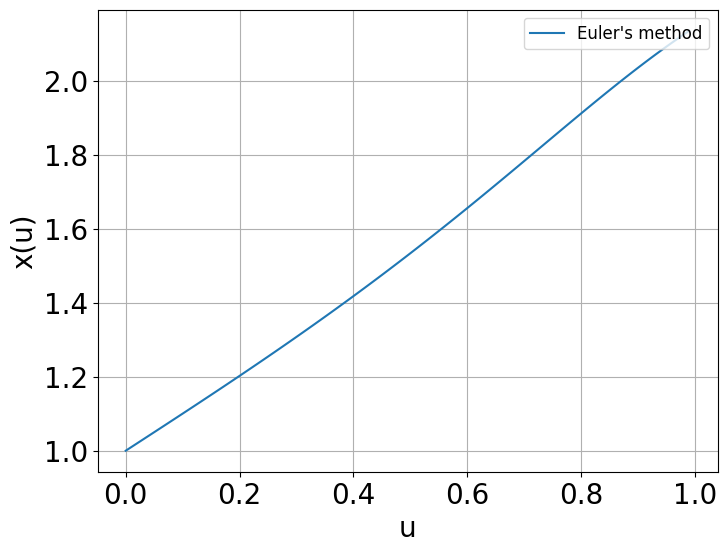

In [35]:
plt.figure(figsize=(8,6))
plt.plot( eul_ex84_u, eul_ex84_x, "-" , label="Euler's method")
plt.xlabel("u" , fontsize=20)
plt.ylabel("x(u)" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.show()

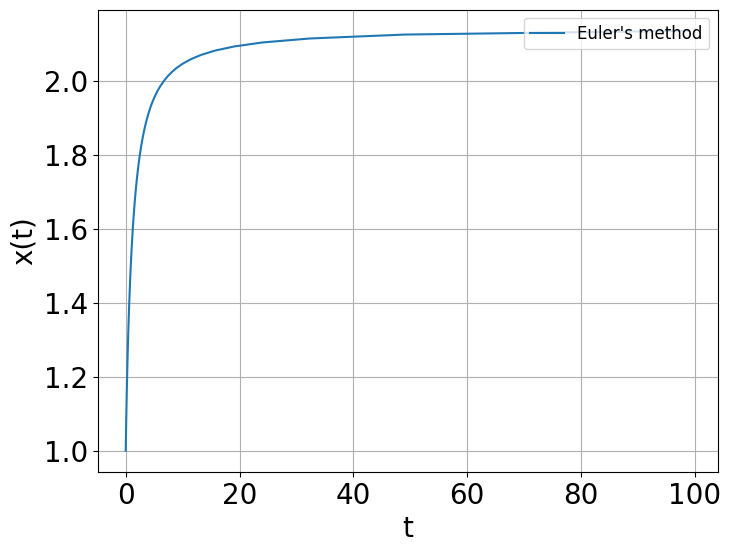

In [36]:
plt.figure(figsize=(8,6))
plt.plot( eul_ex84_t, eul_ex84_x, "-" , label="Euler's method")
plt.xlabel("t" , fontsize=20)
plt.ylabel("x(t)" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.show()

## Solving 2nd order DiffEQ

In [37]:
# Define general functions to solve simultaneous differential equations

# ------------------------------------------------------------------------
# Estimate the solution to a differential equation using Euler's method
def run_euler_vec(a,b,N,r_initial):

    delta_t = (b-a)/N  # find the step size delta_t
    r = r_initial      # Set the initial condition (r is a 1D numpy array (a vector))
    time_array  = np.arange(a,b,delta_t)  # array for iteration
    print("Run Euler: delta_t = ",delta_t, " r_initial = ",r_initial)

    # lists to track x and t for each step
    tpoints  = []
    xpoints  = []
    ypoints  = []

    # loop over the time range with step size delta_t
    for t in time_array:
        #print(r[0],r[1])
        xpoints.append(r[0]) # put the values for this time into the array
        ypoints.append(r[1]) # put the values for this time into the array
        tpoints.append(t) # keep track of the time for plotting
        #  perform euler's method (setup the values for the next time iteration)
        r += delta_t * f(r,t)

    return xpoints, ypoints, tpoints

# ------------------------------------------------------------------------
# Estimate the solution to a differential equation using the midpoint method (2nd order RK)
def run_rk2_vec(a,b,N,r_initial):

    delta_t = (b-a)/N  # find the step size delta_t
    r = r_initial      # Set the initial condition
    time_array  = np.arange(a,b,delta_t)  # array for iteration
    print("Run RK2: delta_t = ",delta_t, " r_initial = ",r_initial)

    # lists to track x and t for each step
    tpoints  = []
    xpoints  = []
    ypoints  = []

    # loop over the time range with step size delta_t
    for t in time_array:
        xpoints.append(r[0]) # put the values for this time into the array
        ypoints.append(r[1]) # put the values for this time into the array
        tpoints.append(t) # keep track of the time for plotting

        # perform 2nd order Runge-Kutta method (setup the values for the next time iteration)
        k1 = delta_t * f( r, t )
        k2 = delta_t * f( r + 0.5*k1 , t + 0.5*delta_t )
        r += k2

    return xpoints, ypoints, tpoints

# ------------- -----------------------------------------------------------
# Estimate the solution to a differential equation using the 4th order RK method
def run_rk4_vec(a,b,N,r_initial):

    delta_t = (b-a)/N  # find the step size delta_t
    r = r_initial      # Set the initial condition
    time_array  = np.arange(a,b,delta_t)  # array for iteration
    print("Run RK4: delta_t = ",delta_t, " r_initial = ",r_initial)

    # lists to track x and t for each step
    tpoints  = []
    xpoints  = []
    ypoints  = []

    # loop over the time range with step size delta_t
    for t in time_array:
        xpoints.append(r[0]) # put the values for this time into the array
        ypoints.append(r[1]) # put the values for this time into the array
        tpoints.append(t) # keep track of the time for plotting

        # perform 4th order Runge-Kutta method
        k1 = delta_t * f(r, t)
        k2 = delta_t * f(r + 0.5*k1 , t + 0.5*delta_t )
        k3 = delta_t * f(r + 0.5*k2 , t + 0.5*delta_t )
        k4 = delta_t * f(r + k3, t + delta_t)
        r += ( k1 + 2*k2 + 2*k3 + k4 )/6
    return xpoints, ypoints, tpoints


# ------------------------------------------------------------------------
# Estimate the solution to a differential equation using the leapfrog method
def run_frg_vec(a,b,N,r_initial):

    delta_t = (b-a)/N  # find the step size delta_t
    t = 0
    r1 = r_initial      # Set the initial point
    r2 = r1 + 0.5*delta_t*f(r1,t) # Set the second point
    time_array  = np.arange(a,b,delta_t)  # array for iteration
    #print("Run LeapFrog: delta_t = ",delta_t, " r_initial = ",r_initial)

    # lists to track x and t for each step
    tpoints  = []
    xpoints  = []
    ypoints  = []

    # loop over the time range with step size delta_t
    for t in time_array:
        xpoints.append(r1[0]) # put the values for this time into the array
        ypoints.append(r1[1]) # put the values for this time into the array
        tpoints.append(t) # keep track of the time for plotting

        # perform leapfrog method (setup the values for the next time iteration)
        r1 += delta_t * f(r2, t)
        r2 += delta_t * f(r1, t)

    return xpoints, ypoints, tpoints


### Non-Linear Pendulum

We can now understand the motion of a pendulum without making any small-angle approximations (see written notes).

In [72]:
# Non-linear pendulum


# constants
g = 9.81
l = 0.1
m = 1

# time range
a = 0
b = 5# 5, 500
N = 5000 # 5000

def f(r,t):
    theta = r[0]
    omega = r[1]
    ftheta = omega
    fomega = -(g/l)*np.sin(theta)
    return np.array([ftheta,fomega],float)


# initial positions
t = 0

start_angle_deg = 120 # Angle in degrees
r = np.array([np.pi*start_angle_deg/180,0.0],float)

x =  l*np.sin(r[0])
y = -l*np.cos(r[0])

print("initial theta, omega = ", r )
print("initial f(theta), f(omega) = ", f(r,t)  )

# Run Euler method
r_init = np.array([np.pi*start_angle_deg/180,0.0],float)
eul_pend_theta, eul_pend_omega, eul_pend_t = run_euler_vec(a, b, N,r_init)

# Run RK2 method
r_init = np.array([np.pi*start_angle_deg/180,0.0],float)
rk2_pend_theta, rk2_pend_omega, rk2_pend_t = run_rk2_vec(a, b, N,r_init)

# Run RK4 method
r_init = np.array([np.pi*start_angle_deg/180,0.0],float)
rk4_pend_theta, rk4_pend_omega, rk4_pend_t = run_rk4_vec(a, b, N,r_init)

# Run LeapFrog method
r_init = np.array([np.pi*start_angle_deg/180,0.0],float)
frg_pend_theta, frg_pend_omega, frg_pend_t = run_frg_vec(a, b, N,r_init)

# Run LeapFrog method - Compare start angles
r_init = np.array([np.pi*5/180,0.0],float)
frg_pend_theta_5degree, frg_pend_omega_5degree, frg_pend_t_5degree = run_frg_vec(a, b, N,r_init)
r_init = np.array([np.pi*10/180,0.0],float)
frg_pend_theta_10degree, frg_pend_omega_10degree, frg_pend_t_10degree = run_frg_vec(a, b, N,r_init)
r_init = np.array([np.pi*45/180,0.0],float)
frg_pend_theta_45degree, frg_pend_omega_45degree, frg_pend_t_45degree = run_frg_vec(a, b, N,r_init)
r_init = np.array([np.pi*90/180,0.0],float)
frg_pend_theta_90degree, frg_pend_omega_90degree, frg_pend_t_90degree = run_frg_vec(a, b, N,r_init)
r_init = np.array([np.pi*120/180,0.0],float)
frg_pend_theta_120degree, frg_pend_omega_120degree, frg_pend_t_120degree = run_frg_vec(a, b, N,r_init)
r_init = np.array([np.pi*170/180,0.0],float)
frg_pend_theta_170degree, frg_pend_omega_170degree, frg_pend_t_170degree = run_frg_vec(a, b, N,r_init)
r_init = np.array([np.pi*179.99/180,0.0],float)
frg_pend_theta_179degree, frg_pend_omega_179degree, frg_pend_t_179degree = run_frg_vec(a, b, N,r_init)


initial theta, omega =  [2.0943951 0.       ]
initial f(theta), f(omega) =  [  0.         -84.95709211]
Run Euler: delta_t =  0.001  r_initial =  [2.0943951 0.       ]
Run RK2: delta_t =  0.001  r_initial =  [2.0943951 0.       ]
Run RK4: delta_t =  0.001  r_initial =  [2.0943951 0.       ]


<>:37: SyntaxWarning: invalid escape sequence '\o'
<>:76: SyntaxWarning: invalid escape sequence '\o'
<>:37: SyntaxWarning: invalid escape sequence '\o'
<>:76: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipython-input-70312748.py:37: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("$\omega$" , fontsize=20)
/tmp/ipython-input-70312748.py:76: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("$\omega$" , fontsize=20)


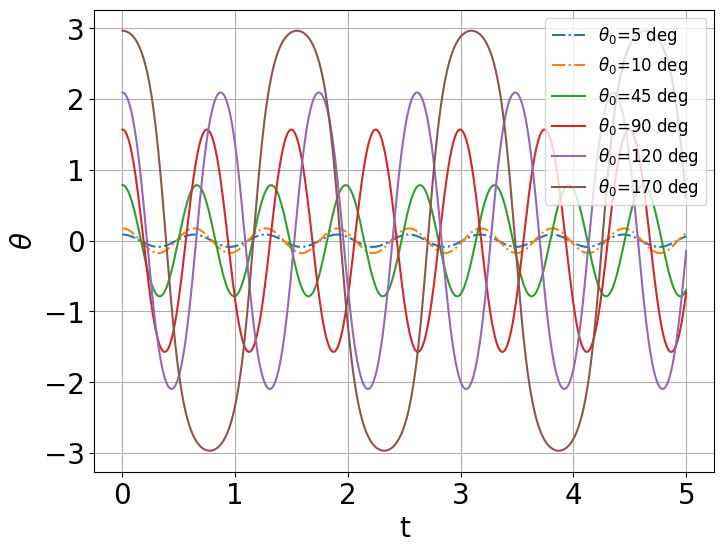

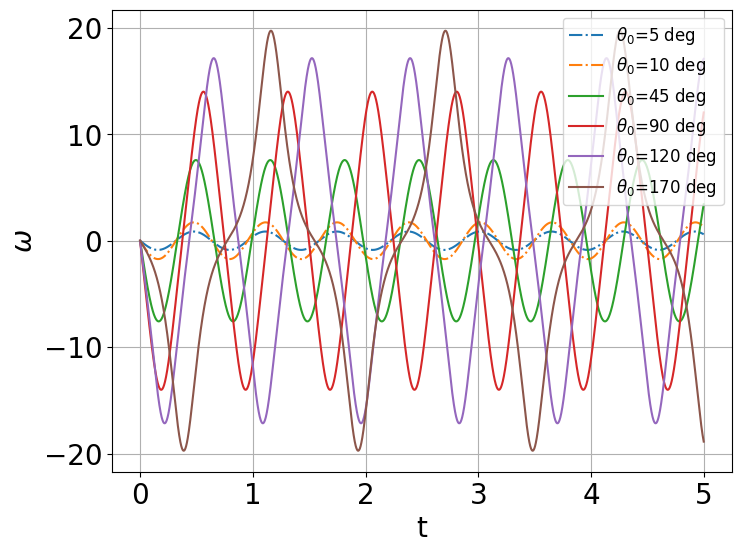

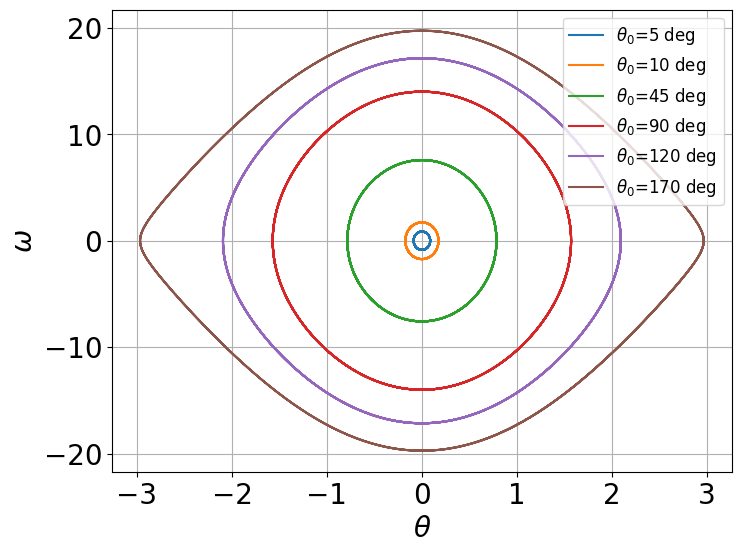

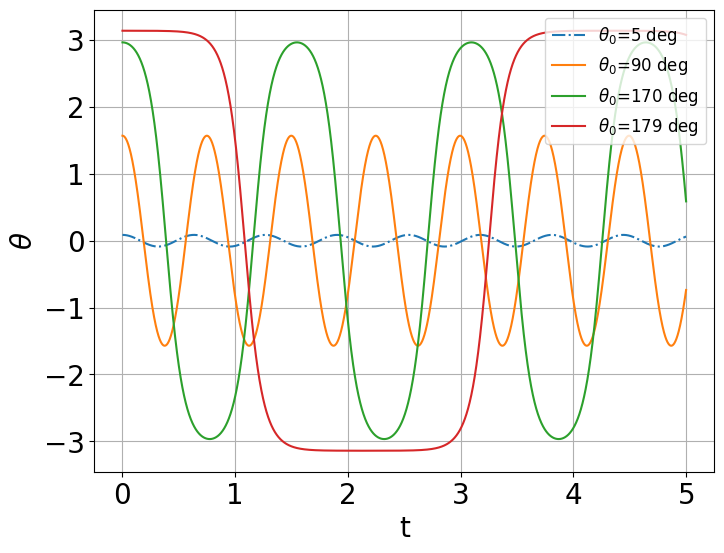

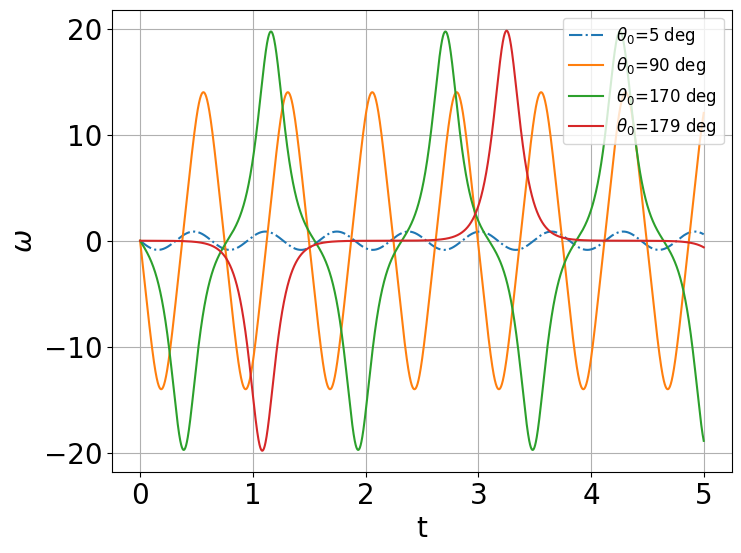

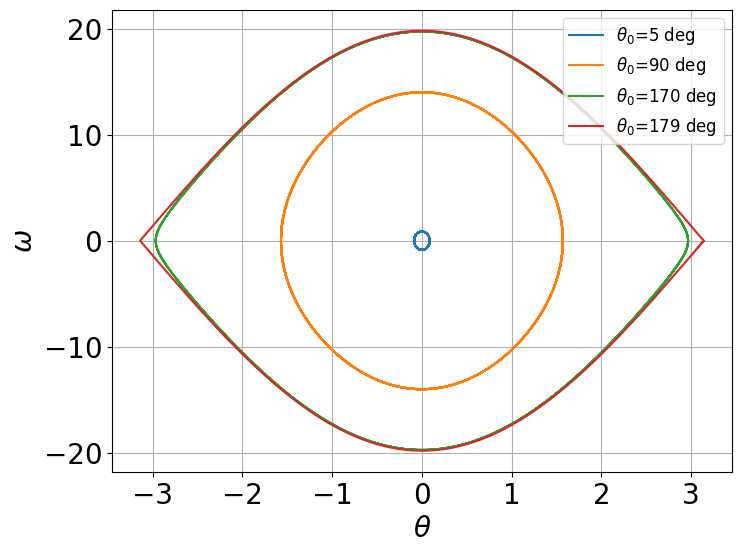

In [73]:
plt.figure(figsize=(8,6))
plt.plot(frg_pend_t_5degree, frg_pend_theta_5degree, "-." , label=r"$\theta_0$=5 deg")
plt.plot(frg_pend_t_10degree, frg_pend_theta_10degree, "-." , label=r"$\theta_0$=10 deg")
plt.plot(frg_pend_t_45degree, frg_pend_theta_45degree, "-" , label=r"$\theta_0$=45 deg")
plt.plot(frg_pend_t_90degree, frg_pend_theta_90degree, "-" , label=r"$\theta_0$=90 deg")
plt.plot(frg_pend_t_120degree, frg_pend_theta_120degree, "-" , label=r"$\theta_0$=120 deg")
plt.plot(frg_pend_t_170degree, frg_pend_theta_170degree, "-" , label=r"$\theta_0$=170 deg")
plt.xlabel("t" , fontsize=20)
plt.ylabel(r"$\theta$" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.plot(frg_pend_t_5degree, frg_pend_omega_5degree, "-." , label=r"$\theta_0$=5 deg")
plt.plot(frg_pend_t_10degree, frg_pend_omega_10degree, "-." , label=r"$\theta_0$=10 deg")
plt.plot(frg_pend_t_45degree, frg_pend_omega_45degree, "-" , label=r"$\theta_0$=45 deg")
plt.plot(frg_pend_t_90degree, frg_pend_omega_90degree, "-" , label=r"$\theta_0$=90 deg")
plt.plot(frg_pend_t_120degree, frg_pend_omega_120degree, "-" , label=r"$\theta_0$=120 deg")
plt.plot(frg_pend_t_170degree, frg_pend_omega_170degree, "-" , label=r"$\theta_0$=170 deg")
plt.xlabel("t" , fontsize=20)
plt.ylabel(r"$\omega$" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.plot(frg_pend_theta_5degree, frg_pend_omega_5degree, "-" , label=r"$\theta_0$=5 deg")
plt.plot(frg_pend_theta_10degree, frg_pend_omega_10degree, "-" , label=r"$\theta_0$=10 deg")
plt.plot(frg_pend_theta_45degree, frg_pend_omega_45degree, "-" , label=r"$\theta_0$=45 deg")
plt.plot(frg_pend_theta_90degree, frg_pend_omega_90degree, "-" , label=r"$\theta_0$=90 deg")
plt.plot(frg_pend_theta_120degree, frg_pend_omega_120degree, "-" , label=r"$\theta_0$=120 deg")
plt.plot(frg_pend_theta_170degree, frg_pend_omega_170degree, "-" , label=r"$\theta_0$=170 deg")
plt.xlabel(r"$\theta$" , fontsize=20)
plt.ylabel("$\omega$" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.show()


plt.figure(figsize=(8,6))
plt.plot(frg_pend_t_5degree, frg_pend_theta_5degree, "-." , label=r"$\theta_0$=5 deg")
plt.plot(frg_pend_t_90degree, frg_pend_theta_90degree, "-" , label=r"$\theta_0$=90 deg")
plt.plot(frg_pend_t_170degree, frg_pend_theta_170degree, "-" , label=r"$\theta_0$=170 deg")
plt.plot(frg_pend_t_179degree, frg_pend_theta_179degree, "-" , label=r"$\theta_0$=179 deg")
plt.xlabel("t" , fontsize=20)
plt.ylabel(r"$\theta$" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.plot(frg_pend_t_5degree, frg_pend_omega_5degree, "-." , label=r"$\theta_0$=5 deg")
plt.plot(frg_pend_t_90degree, frg_pend_omega_90degree, "-" , label=r"$\theta_0$=90 deg")
plt.plot(frg_pend_t_170degree, frg_pend_omega_170degree, "-" , label=r"$\theta_0$=170 deg")
plt.plot(frg_pend_t_179degree, frg_pend_omega_179degree, "-" , label=r"$\theta_0$=179 deg")

plt.xlabel("t" , fontsize=20)
plt.ylabel(r"$\omega$" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.plot(frg_pend_theta_5degree, frg_pend_omega_5degree, "-" , label=r"$\theta_0$=5 deg")
plt.plot(frg_pend_theta_90degree, frg_pend_omega_90degree, "-" , label=r"$\theta_0$=90 deg")
plt.plot(frg_pend_theta_170degree, frg_pend_omega_170degree, "-" , label=r"$\theta_0$=170 deg")
plt.plot(frg_pend_theta_179degree, frg_pend_omega_179degree, "-" , label=r"$\theta_0$=179 deg")

plt.xlabel(r"$\theta$" , fontsize=20)
plt.ylabel("$\omega$" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.show()



Above we see that the period of a high angle pendulum no longer follows our assumptions from intro physics. The phase diagram demonstrates that energy is conserved (it is a closed loop) but the shape is no longer an ellipse. This is because the potential well is not parabolic (it does not get steeper and steeper forever). Instead the potential depends on $1-cos(\theta)$ and it flattens out as the angle approaches the top. The high angle pendulum slows down and "lingers" at its turning points for longer than a simple harmonic oscillator would. This "lingering" at the high-angle ends of the swing is what distorts the perfect ellipse into that more "distorted" closed loop.

Let's try making a pretty (but useless) plot:

<>:38: SyntaxWarning: invalid escape sequence '\o'
<>:38: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipython-input-3549960030.py:38: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("$\omega$ (rad/s)" , fontsize=20)


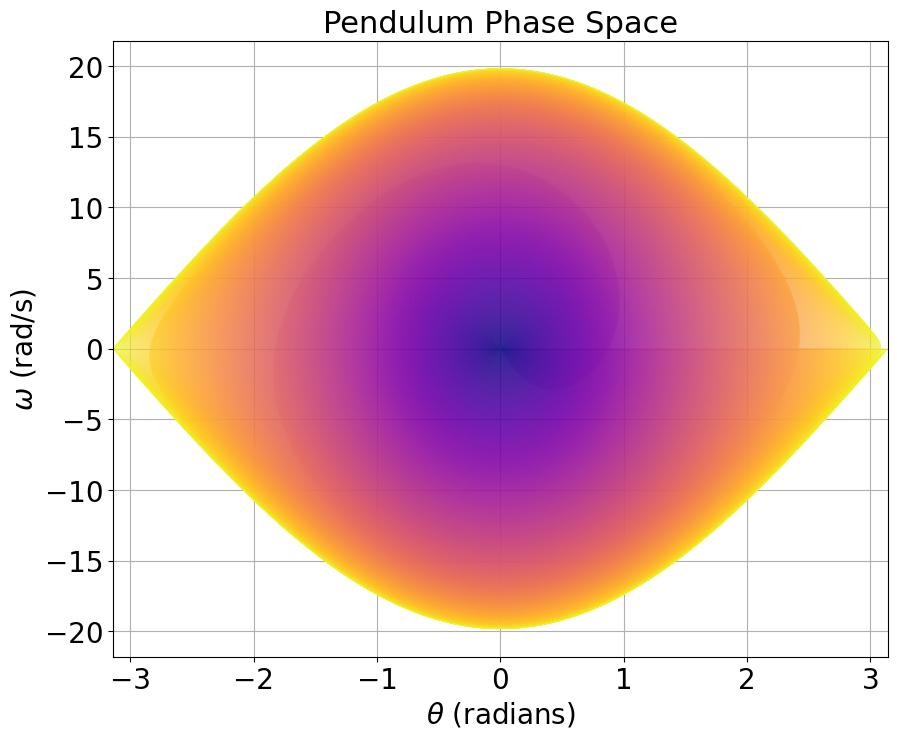

In [70]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

a2 = 0
b2 = 2
N2 = 1000

# (from 0.1 degrees up to 179.9, in 0.1 degree steps)
angles_to_run = np.arange(0.1, 180.0, 0.1)

# 'plasma', 'viridis', 'cool', or 'hsv'
cmap = plt.get_cmap('plasma')
num_angles = len(angles_to_run)

# Loop through every angle, run the simulation, and plot
for i, start_angle_deg in enumerate(angles_to_run):

    # Set initial conditions for this angle
    r_init = np.array([np.pi * start_angle_deg / 180.0, 0.0], float)

    # Run the LeapFrog simulation
    frg_pend_theta, frg_pend_omega, frg_pend_t = run_frg_vec(a2, b2, N2, r_init)

    # Map the current angle's index (0 to num_angles) to a color value (0.0 to 1.0)
    color_value = float(i) / num_angles

    # Plot this one trajectory
    plt.plot(frg_pend_theta, frg_pend_omega,
             "-",
             color=cmap(color_value),
             linewidth=0.5,  # Thinner lines look better when crowded
             alpha=0.3)       # Use transparency to build up color

# Set labels and formatting *after* the loop is done
plt.xlabel(r"$\theta$ (radians)" , fontsize=20)
plt.ylabel("$\omega$ (rad/s)" , fontsize=20)
plt.title("Pendulum Phase Space", fontsize=22)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.xlim(-np.pi, np.pi)
plt.show()

Now let's compare diffeq solvers:

<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:33: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:33: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipython-input-609930017.py:20: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("$\omega$" , fontsize=20)
/tmp/ipython-input-609930017.py:33: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("$\omega$" , fontsize=20)


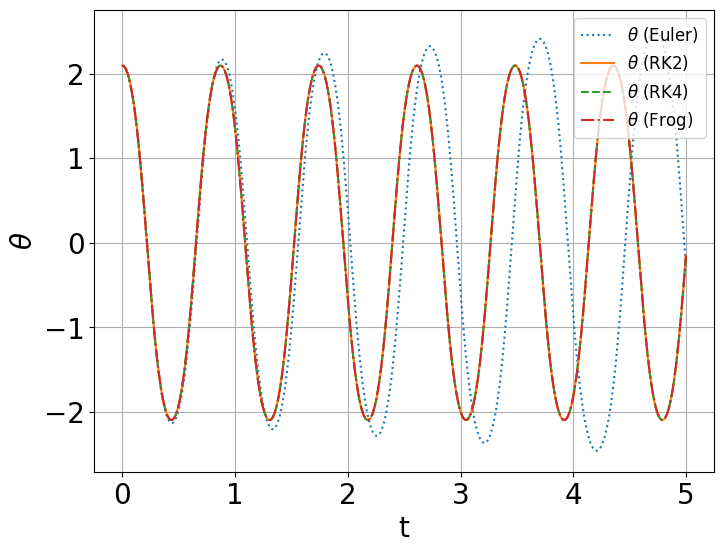

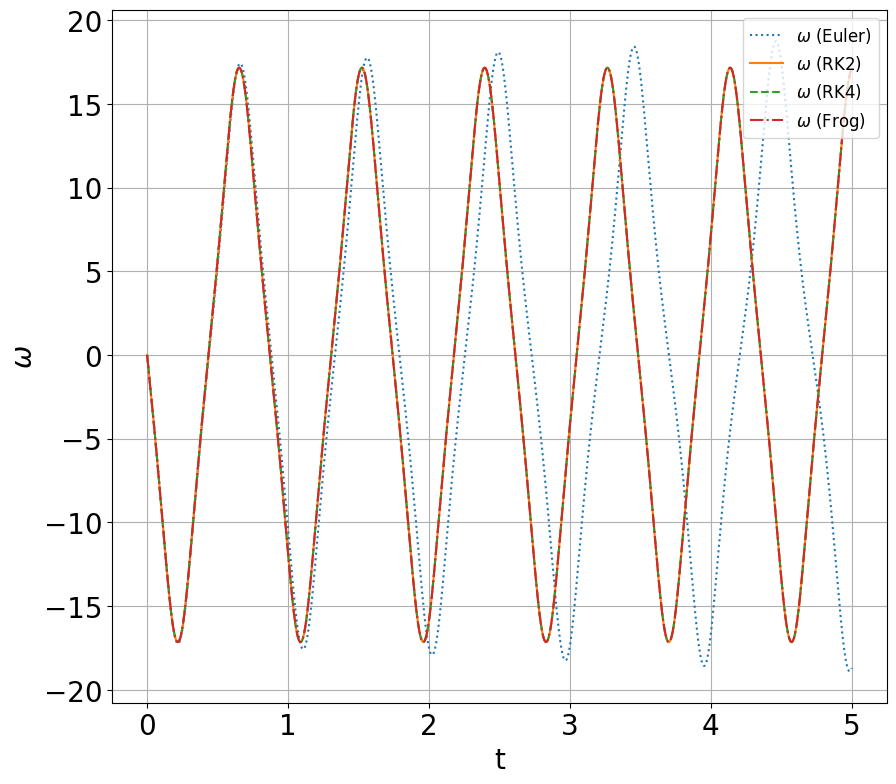

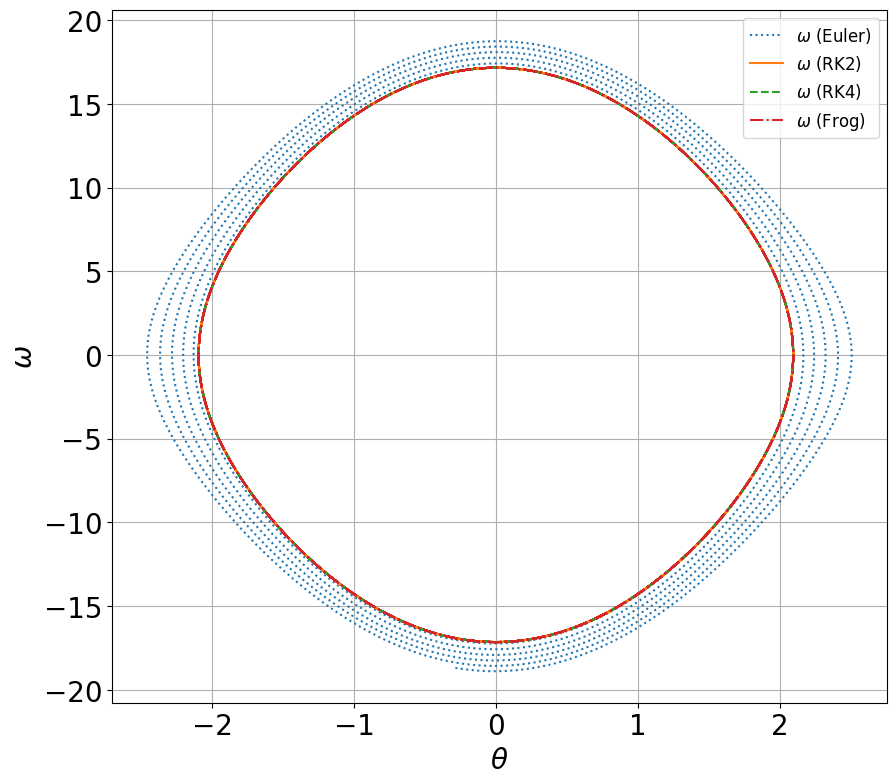

In [74]:

plt.figure(figsize=(8,6))
plt.plot(eul_pend_t, eul_pend_theta, ":" , label=r"$\theta$ (Euler)")
plt.plot(rk2_pend_t, rk2_pend_theta, "-" , label=r"$\theta$ (RK2)")
plt.plot(rk4_pend_t, rk4_pend_theta, "--" , label=r"$\theta$ (RK4)")
plt.plot(frg_pend_t, frg_pend_theta, "-." , label=r"$\theta$ (Frog)")
plt.xlabel("t" , fontsize=20)
plt.ylabel(r"$\theta$" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.show()


plt.figure(figsize=(10,9))
plt.plot(eul_pend_t,eul_pend_omega,  ":" , label=r"$\omega$ (Euler)")
plt.plot(rk2_pend_t,rk2_pend_omega,  "-" , label=r"$\omega$ (RK2)")
plt.plot(rk4_pend_t,rk4_pend_omega, "--" , label=r"$\omega$ (RK4)")
plt.plot(frg_pend_t,frg_pend_omega, "-." , label=r"$\omega$ (Frog)")
plt.xlabel("t" , fontsize=20)
plt.ylabel("$\omega$" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.show()


plt.figure(figsize=(10,9))
plt.plot(eul_pend_theta, eul_pend_omega, ":" , label=r"$\omega$ (Euler)")
plt.plot(rk2_pend_theta, rk2_pend_omega, "-" , label=r"$\omega$ (RK2)")
plt.plot(rk4_pend_theta, rk4_pend_omega, "--", label=r"$\omega$ (RK4)")
plt.plot(frg_pend_theta, frg_pend_omega, "-.", label=r"$\omega$ (Frog)")
plt.xlabel(r"$\theta$" , fontsize=20)
plt.ylabel("$\omega$" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.show()

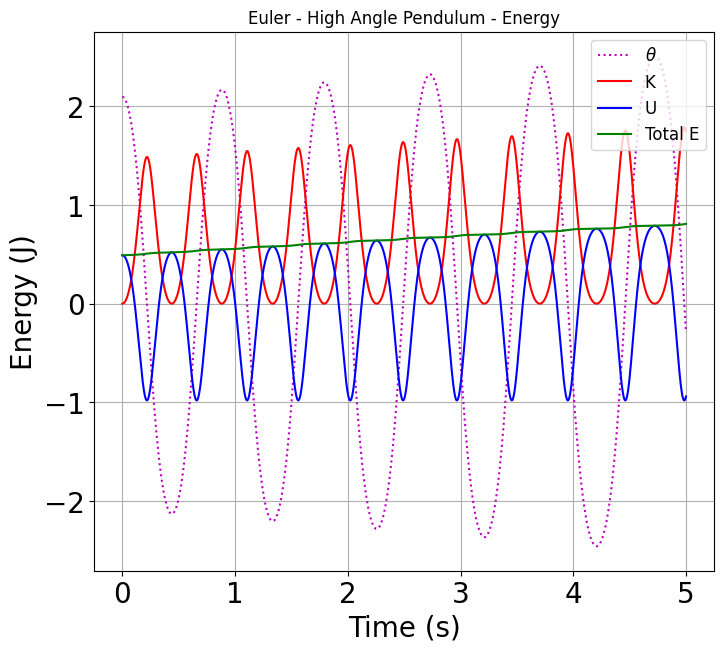

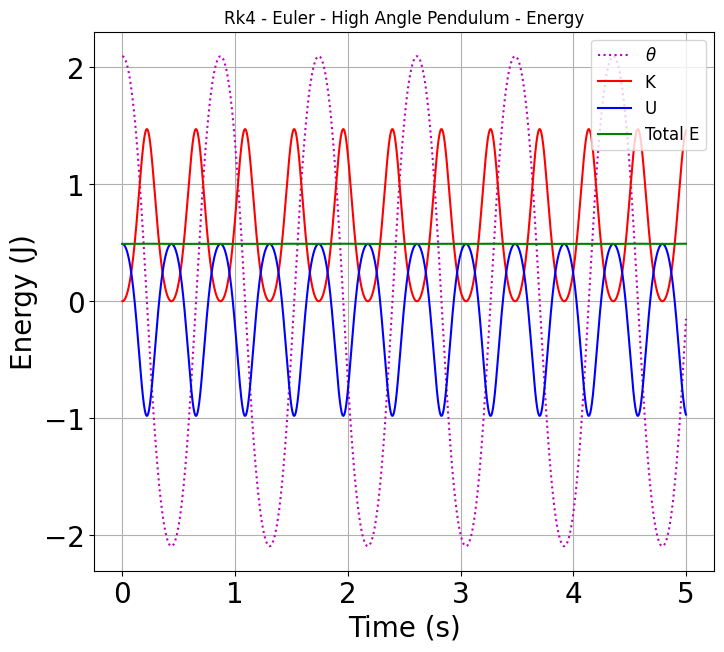

In [75]:
### Calculate Energies

# Convert theta & omega lists to numpy arrays for each method
a_eul_theta  = np.array(eul_pend_theta  , float)
a_eul_omega  = np.array(eul_pend_omega  , float)
a_rk2_theta  = np.array(rk2_pend_theta  , float)
a_rk2_omega  = np.array(rk2_pend_omega  , float)
a_rk4_theta  = np.array(rk4_pend_theta  , float)
a_rk4_omega  = np.array(rk4_pend_omega  , float)
a_frg_theta  = np.array(frg_pend_theta  , float)
a_frg_omega  = np.array(frg_pend_omega  , float)

# Kinetic energy
a_eul_K = 0.5 * m * l * l * a_eul_omega * a_eul_omega  # K = 1/2 I omeaga^2, I = mr^2. K = 1/2 m v^2, v = r*omega.
a_rk2_K = 0.5 * m * l * l * a_rk2_omega * a_rk2_omega  # K = 1/2 I omeaga^2, I = mr^2. K = 1/2 m v^2, v = r*omega.
a_rk4_K = 0.5 * m * l * l * a_rk4_omega * a_rk4_omega  # K = 1/2 I omeaga^2, I = mr^2. K = 1/2 m v^2, v = r*omega.
a_frg_K = 0.5 * m * l * l * a_frg_omega * a_frg_omega  # K = 1/2 I omeaga^2, I = mr^2. K = 1/2 m v^2, v = r*omega.

# height
a_eul_y = -l * np.cos(a_eul_theta) # pivot point is y = 0. lowest point is y = -l.
a_rk2_y = -l * np.cos(a_rk2_theta) # pivot point is y = 0. lowest point is y = -l.
a_rk4_y = -l * np.cos(a_rk4_theta) # pivot point is y = 0. lowest point is y = -l.
a_frg_y = -l * np.cos(a_frg_theta) # pivot point is y = 0. lowest point is y = -l.

# Potential energy
a_eul_U = m * 9.8 * a_eul_y
a_rk2_U = m * 9.8 * a_rk2_y
a_rk4_U = m * 9.8 * a_rk4_y
a_frg_U = m * 9.8 * a_frg_y

# Total energy
a_eul_T = a_eul_K + a_eul_U
a_rk2_T = a_rk2_K + a_rk2_U
a_rk4_T = a_rk4_K + a_rk4_U
a_frg_T = a_frg_K + a_frg_U

### Plot

plt.figure(figsize=(8,7))
plt.plot(eul_pend_t, a_eul_theta, "m:" , label=r'$\theta$') # label=r'text' -> raw string for latex use
plt.plot(eul_pend_t, a_eul_K    , "r"  , label=r'K') # label=r'text' -> raw string for latex use
plt.plot(eul_pend_t, a_eul_U    , "b"  , label=r'U') # label=r'text' -> raw string for latex use
plt.plot(eul_pend_t, a_eul_T, "g" , label=r'Total E') # label=r'text' -> raw string for latex use
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.title('Euler - High Angle Pendulum - Energy')
plt.xlabel("Time (s)" , fontsize=20)
plt.ylabel("Energy (J)" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.show()

plt.figure(figsize=(8,7))
plt.plot(rk4_pend_t, a_rk4_theta, "m:" , label=r'$\theta$') # label=r'text' -> raw string for latex use
plt.plot(rk4_pend_t, a_rk4_K    , "r"  , label=r'K') # label=r'text' -> raw string for latex use
plt.plot(rk4_pend_t, a_rk4_U    , "b"  , label=r'U') # label=r'text' -> raw string for latex use
plt.plot(rk4_pend_t, a_rk4_T, "g" , label=r'Total E') # label=r'text' -> raw string for latex use
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.title('Rk4 - Euler - High Angle Pendulum - Energy')
plt.xlabel("Time (s)" , fontsize=20)
plt.ylabel("Energy (J)" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.show()


As we have seen, Euler seems to fail. It turns out that RK2 and RK4 also don't perfectly conserve energy over long periods of time. With Euler the energy drifts away very fast ($E \propto t$). With RK4 the energy drifts away slowly ($E \propto t \cdot dt^4$). The leapfrog method is designed to address this. Energy oscillates around the true, constant value. It does not drift. The error stays bounded forever.

The LeapFrog method is part of a special class of solvers called symplectic integrators. While RK4 is a fantastic general-purpose solver, it works by being extremely accurate at each step. However, over thousands of steps, small errors can accumulate, leading to a slow "drift" in the total energy of a conservative system.

Symplectic integrators, like LeapFrog, are designed differently. They might not be as accurate as RK4 at any single point, but they are designed to preserve the geometric structure of the system's phase space.

In simple terms: Symplectic integrators are built to conserve energy over very long simulation times. The energy will oscillate around the true value instead of drifting away.

There are also other common Symplectic integrators like "velocity verlet".

Symplectic integrators have the following properties:

1.  **Time-Reversibility:** The algorithm is perfectly time-reversible. If you run a simulation forward for 1000 steps, then flip the sign of the velocity and run it backward for 1000 steps, you will end up *exactly* where you started. This is a core property of conservative physical systems.

2.  **Phase Space Conservation:** Because it's time-reversible, it correctly preserves the "geometry of phase space."

3.  **Bounded Energy Error:** The result of this is that the numerical error in the total energy does **not** accumulate and "drift" over time (like it does in Euler or RK4). Instead, the calculated energy **oscillates in a bounded way** around the true, constant energy of the system.

For very long simulations (like modeling a solar system or a protein folding), this is far more important than the per-step accuracy of RK4. The "drift" from RK4 would eventually destroy the simulation, while the "oscillation" from Leapfrog or Velocity Verlet keeps the simulation physically stable forever.

Note: Symplectic integrators like "LeapFrog" and "velocity verlet" are not built-in to SciPy. Typically you have to implemnt them yourself or use other libraries (astropy, gala for galactic dynamics)


In [76]:
def run_verlet_vec(a, b, N, r_init):
    """
    Solves the pendulum ODE using the Velocity Verlet algorithm.

    r_init = [initial_theta, initial_omega]
    a, b = time range
    N = number of steps
    """
    w = (b-a)/N
    t_points = np.arange(a, b, w)

    theta_points = []
    omega_points = []

    r = np.array(r_init, float)

    for t in t_points:
        # Store the current state (theta, omega) at time t
        theta_points.append(r[0])
        omega_points.append(r[1])

        # Unpack current position and velocity
        theta_t = r[0]
        omega_t = r[1]

        # 1. Get current acceleration a(t)
        # f(r,t)[1] gives fomega, which is the acceleration a(t)
        a_t = f(r, t)[1]

        # 2. Calculate new position theta(t+w)
        # theta(t+w) = theta(t) + omega(t)*w + 0.5*a(t)*w^2
        theta_t_plus_w = theta_t + omega_t*w + 0.5*a_t*w*w

        # 3. Calculate new acceleration a(t+w)
        # We need to get the acceleration at the *new* position.
        # Our acceleration f(r,t)[1] only depends on theta.
        # So we create a temporary state vector with the new theta.
        # (The omega value here doesn't matter, as f[1] doesn't use it)
        r_temp_for_accel = np.array([theta_t_plus_w, omega_t], float)
        a_t_plus_w = f(r_temp_for_accel, t + w)[1]

        # 4. Calculate new velocity omega(t+w) using an average of the old and new acceleration
        # omega(t+w) = omega(t) + 0.5 * (a(t) + a(t+w)) * w
        omega_t_plus_w = omega_t + 0.5 * (a_t + a_t_plus_w) * w

        # 5. Update the state vector r for the next loop
        r = np.array([theta_t_plus_w, omega_t_plus_w], float)

    return theta_points, omega_points, t_points

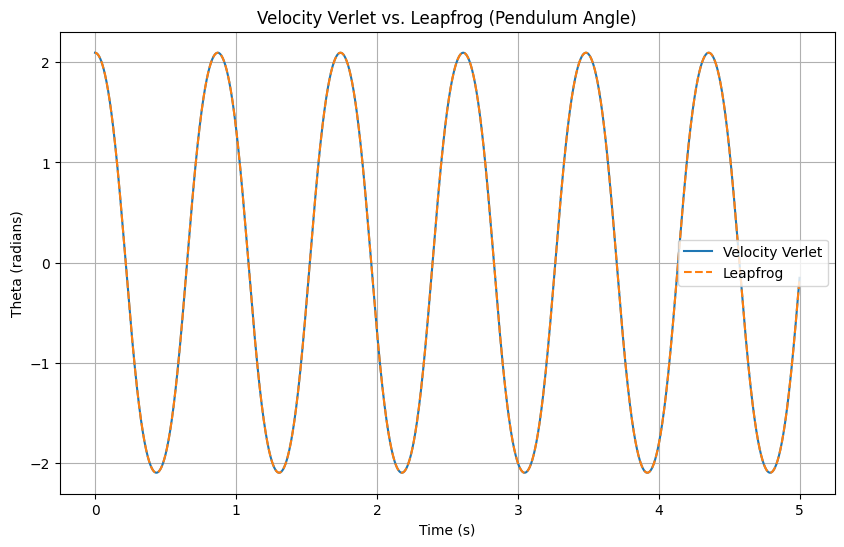

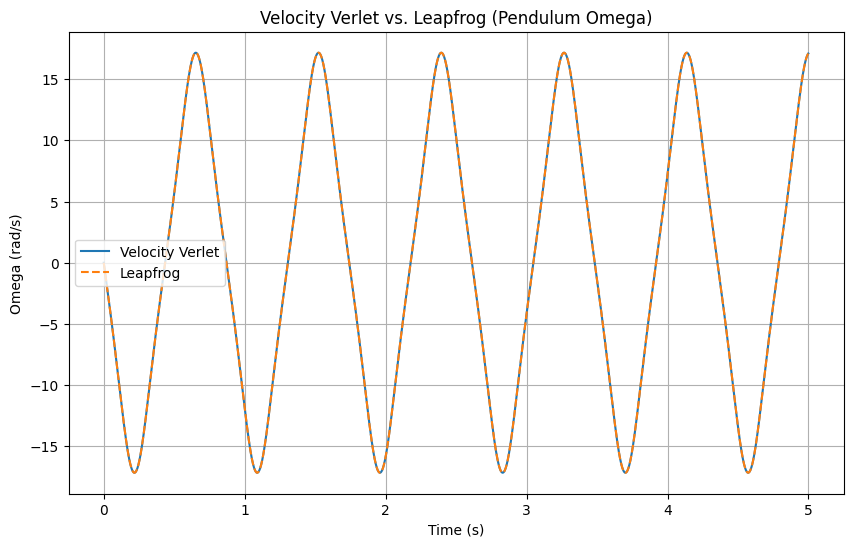

In [77]:
g = 9.81
l = 0.1
m = 1

a = 0
b = 5
N = 5000

def f(r,t):
    theta = r[0]
    omega = r[1]
    ftheta = omega
    fomega = -(g/l)*np.sin(theta)
    return np.array([ftheta,fomega],float)

start_angle_deg = 120
r_init = np.array([np.pi*start_angle_deg/180,0.0],float)

# --- Run Velocity Verlet method ---
vlt_pend_theta, vlt_pend_omega, vlt_pend_t = run_verlet_vec(a, b, N, r_init)

# --- You can now plot it just like your other methods ---
plt.figure(figsize=(10, 6))
plt.plot(vlt_pend_t, vlt_pend_theta, label='Velocity Verlet')
plt.plot(frg_pend_t, frg_pend_theta, label='Leapfrog', linestyle='--') # For comparison
plt.title('Velocity Verlet vs. Leapfrog (Pendulum Angle)')
plt.xlabel('Time (s)')
plt.ylabel('Theta (radians)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(vlt_pend_t, vlt_pend_omega, label='Velocity Verlet')
plt.plot(frg_pend_t, frg_pend_omega, label='Leapfrog', linestyle='--') # For comparison
plt.title('Velocity Verlet vs. Leapfrog (Pendulum Omega)')
plt.xlabel('Time (s)')
plt.ylabel('Omega (rad/s)')
plt.legend()
plt.grid(True)
plt.show()

### Built-in tools



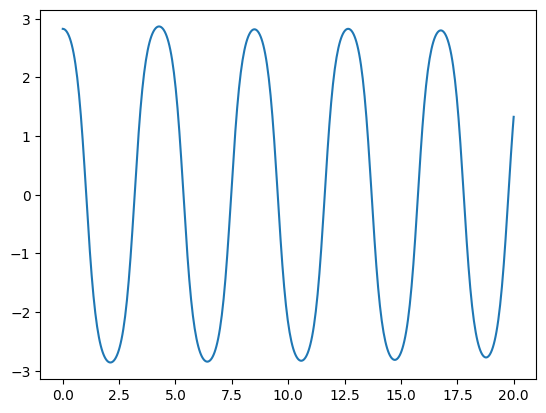

In [45]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

# Use the same pendulum model you already defined
def pendulum_model(t, r):
     g = 9.8
     l = 1.0
     theta, omega = r
     dtheta_dt = omega
     domega_dt = -(g/l) * np.sin(theta)
     return [dtheta_dt, domega_dt]

# Initial conditions and time span
r_initial = [np.pi * 0.9, 0.0]  # [theta_0, omega_0]
t_span = [0, 20]                # Solve from t=0 to t=20
t_eval = np.linspace(0, 20, 500) # Points where you want the solution

# Run the solver!
sol = solve_ivp(
    pendulum_model,
    t_span,
    r_initial,
    t_eval=t_eval,
    method='RK45'
)

# The results are in sol.t (time) and sol.y (solution)
plt.plot(sol.t, sol.y[0], label='theta(t) from SciPy')
plt.show()

### Projectile trajectory with air resistance

In [46]:
# Estimate the trajectory of a ball subjected to F_grav and F_drag
#  using the 4th order Runge-Kutta (RK) method

import numpy as np
import matplotlib.pyplot as plt


# Default constant definitions and initial conditions
#  constants
g   = 9.81       # acceleration due to gravity [m/s^2]
m   = 1.0        # mass = 1 kg
rho = 1.22       # air density [kg/m^3]
D   = 0.47       # Drag coefficient
R   = 0.08       # Radius of sphere [m]

#  initial conditions
h     = 0 # intitial height above the ground
theta = 75   # launch angle [degrees converted to radians]
v0    = 100  # initial velocity [m/s]

#  Set the time step for estimating the differential equation solution
delta_t = 0.1   # [s]


def f(r,const,g):
    x  = r[0]
    y  = r[1]
    vx = r[2]
    vy = r[3]
    fx = vx
    fy = vy
    fvx = -const*vx*np.sqrt(vx*vx+vy*vy)
    fvy = -const*vy*np.sqrt(vx*vx+vy*vy) - g
    #print("fx  = ",fx)
    #print("fy  = ",fy)
    #print("fvx = ",fvx)
    #print("fvy = ",fvy)
    return np.array( [fx,fy,fvx,fvy], float )


def trajectory(h, theta, v0, g, m, rho, D, R, delta_t):

    print("Find trajectory","h",h,", theta",theta,", v0",v0, ", g",g,", m", m,", rho", rho,", D",D,", R", R,", delta_t", delta_t)
    # Define constant
    c = (rho*D*np.pi*R*R)/(2*m)

    # Convert launch angle to radians
    theta*=   np.pi / 180

    # Initiate array containting position and velocity [x,y,vx,vy]
    #   x_i = 0  (initial x position)
    #   y_i = 0  (initial x position)
    #   vx_i = |v_i|cos(theta)  (x-component of initial velocity vector)
    #   vy_i = |v_i|sin(theta)  (y-component of initial velocity vector)
    r = np.array([ 0.0, h, v0*np.cos(theta), v0*np.sin(theta)] )

    # Store the x and y position for each time step
    l_x  = []
    l_y  = []
    l_vx = []
    l_vy = []
    l_t  = []

    # Time loop
    time=0
    while r[1] >= 0.0:  # stay in loop as long as you are above height = 0 (above the ground)
        #print("height = ",r[1] )
        l_x.append(r[0])
        l_y.append(r[1])
        l_vx.append(r[2])
        l_vy.append(r[3])
        l_t.append(time)
        time += delta_t

        # perform 4th order Runge-Kutta method
        k1 = delta_t * f(r,c,g)
        k2 = delta_t * f(r+0.5*k1,c,g)
        k3 = delta_t * f(r+0.5*k2,c,g)
        k4 = delta_t * f(r+k3,c,g)
        r += (k1+2*k2+2*k3+k4)/6


    return l_x, l_y, l_vx, l_vy, l_t

In [47]:
temp_theta = 75
temp_delta_t = 0.25

# def trajectory(h, theta, v0, g, m, rho, D, R, delta_t):
#b0_x, b0_y, b0_vx, b0_vy, b0_t = trajectory(h, temp_theta, v0, g, m, rho, 3, 0.01, temp_delta_t)


# ------------------------------------------------------
# Trajectory with no air resistance

b0_x, b0_y, b0_vx, b0_vy, b0_t = trajectory(h, temp_theta, v0, g, m, rho, 0, 0.01, temp_delta_t)
c0_x, c0_y, c0_vx, c0_vy, c0_t = trajectory(h, temp_theta, v0, g, 4, rho, 0, 0.01, temp_delta_t)

# ------------------------------------------------------
# Trajectory with air resistance for different ball sizes
b1_x, b1_y, b1_vx, b1_vy, b1_t = trajectory(h, temp_theta, v0, g, m, rho, D, 0.01, temp_delta_t)
b2_x, b2_y, b2_vx, b2_vy, b2_t = trajectory(h, temp_theta, v0, g, m, rho, D, 0.02, temp_delta_t)
b3_x, b3_y, b3_vx, b3_vy, b3_t = trajectory(h, temp_theta, v0, g, m, rho, D, 0.03, temp_delta_t)
b4_x, b4_y, b4_vx, b4_vy, b4_t = trajectory(h, temp_theta, v0, g, m, rho, D, 0.04, temp_delta_t)
b5_x, b5_y, b5_vx, b5_vy, b5_t = trajectory(h, temp_theta, v0, g, m, rho, D, 0.05, temp_delta_t)
b6_x, b6_y, b6_vx, b6_vy, b6_t = trajectory(h, temp_theta, v0, g, m, rho, D, 0.06, temp_delta_t)


# ------------------------------------------------------
# Trajectory with air resistance for different masses
c1_x, c1_y, c1_vx, c1_vy, c1_t = trajectory(h, temp_theta, v0, g, m, rho, D, 0.04, temp_delta_t)
c2_x, c2_y, c2_vx, c2_vy, c2_t = trajectory(h, temp_theta, v0, g, 2*m, rho, D, 0.04, temp_delta_t)
c3_x, c3_y, c3_vx, c3_vy, c3_t = trajectory(h, temp_theta, v0, g, 3*m, rho, D, 0.04, temp_delta_t)
c4_x, c4_y, c4_vx, c4_vy, c4_t = trajectory(h, temp_theta, v0, g, 4*m, rho, D, 0.04, temp_delta_t)




# ------------------------------------------------------
# Trajectory with air resistance for different launch angles
d1_x, d1_y, d1_vx, d1_vy, d1_t = trajectory(h, 10, v0, g, m, rho, D, 0.04, temp_delta_t)
d2_x, d2_y, d2_vx, d2_vy, d2_t = trajectory(h, 20, v0, g, m, rho, D, 0.04, temp_delta_t)
d3_x, d3_y, d3_vx, d3_vy, d3_t = trajectory(h, 30, v0, g, m, rho, D, 0.04, temp_delta_t)
d4_x, d4_y, d4_vx, d4_vy, d4_t = trajectory(h, 40, v0, g, m, rho, D, 0.04, temp_delta_t)
d5_x, d5_y, d5_vx, d5_vy, d5_t = trajectory(h, 50, v0, g, m, rho, D, 0.04, temp_delta_t)
d6_x, d6_y, d6_vx, d6_vy, d6_t = trajectory(h, 60, v0, g, m, rho, D, 0.04, temp_delta_t)
d7_x, d7_y, d7_vx, d7_vy, d7_t = trajectory(h, 70, v0, g, m, rho, D, 0.04, temp_delta_t)
d8_x, d8_y, d8_vx, d8_vy, d8_t = trajectory(h, 80, v0, g, m, rho, D, 0.04, temp_delta_t)
d9_x, d9_y, d9_vx, d9_vy, d9_t = trajectory(h, 90, v0, g, m, rho, D, 0.04, temp_delta_t)


# ------------------------------------------------------
# Trajectory without air resistance for different launch angles
e1_x, e1_y, e1_vx, e1_vy, e1_t = trajectory(h, 10, v0, g, m, rho, 0, 0.04, temp_delta_t)
e2_x, e2_y, e2_vx, e2_vy, e2_t = trajectory(h, 20, v0, g, m, rho, 0, 0.04, temp_delta_t)
e3_x, e3_y, e3_vx, e3_vy, e3_t = trajectory(h, 30, v0, g, m, rho, 0, 0.04, temp_delta_t)
e4_x, e4_y, e4_vx, e4_vy, e4_t = trajectory(h, 40, v0, g, m, rho, 0, 0.04, temp_delta_t)
e5_x, e5_y, e5_vx, e5_vy, e5_t = trajectory(h, 50, v0, g, m, rho, 0, 0.04, temp_delta_t)
e6_x, e6_y, e6_vx, e6_vy, e6_t = trajectory(h, 60, v0, g, m, rho, 0, 0.04, temp_delta_t)
e7_x, e7_y, e7_vx, e7_vy, e7_t = trajectory(h, 70, v0, g, m, rho, 0, 0.04, temp_delta_t)
e8_x, e8_y, e8_vx, e8_vy, e8_t = trajectory(h, 80, v0, g, m, rho, 0, 0.04, temp_delta_t)
e9_x, e9_y, e9_vx, e9_vy, e9_t = trajectory(h, 90, v0, g, m, rho, 0, 0.04, temp_delta_t)



# ------------------------------------------------------
# Trajectory with air resistance for different launch angles (smaller variation)
f1_x, f1_y, f1_vx, f1_vy, f1_t = trajectory(h, 38, v0, g, m, rho, D, 0.04, 0.1)
f2_x, f2_y, f2_vx, f2_vy, f2_t = trajectory(h, 39, v0, g, m, rho, D, 0.04, 0.1)
f3_x, f3_y, f3_vx, f3_vy, f3_t = trajectory(h, 40, v0, g, m, rho, D, 0.04, 0.1)
f4_x, f4_y, f4_vx, f4_vy, f4_t = trajectory(h, 41, v0, g, m, rho, D, 0.04, 0.1)
f5_x, f5_y, f5_vx, f5_vy, f5_t = trajectory(h, 42, v0, g, m, rho, D, 0.04, 0.1)
f6_x, f6_y, f6_vx, f6_vy, f6_t = trajectory(h, 43, v0, g, m, rho, D, 0.04, 0.1)
f7_x, f7_y, f7_vx, f7_vy, f7_t = trajectory(h, 44, v0, g, m, rho, D, 0.04, 0.1)
f8_x, f8_y, f8_vx, f8_vy, f8_t = trajectory(h, 45, v0, g, m, rho, D, 0.04, 0.1)
f9_x, f9_y, f9_vx, f9_vy, f9_t = trajectory(h, 46, v0, g, m, rho, D, 0.04, 0.1)



# ------------------------------------------------------
# Trajectory without air resistance for different launch angles

g0_x, g0_y, g0_vx, g0_vy, g0_t = trajectory(700,   0, v0, g, m, rho, 0, 0.04, temp_delta_t)

g3_x, g3_y, g3_vx, g3_vy, g3_t = trajectory(700, -30, v0, g, m, rho, 0, 0.04, temp_delta_t)
g4_x, g4_y, g4_vx, g4_vy, g4_t = trajectory(700,  30, v0, g, m, rho, 0, 0.04, temp_delta_t)
g5_x, g5_y, g5_vx, g5_vy, g5_t = trajectory(700, -60, v0, g, m, rho, 0, 0.04, temp_delta_t)
g6_x, g6_y, g6_vx, g6_vy, g6_t = trajectory(700,  60, v0, g, m, rho, 0, 0.04, temp_delta_t)
g7_x, g7_y, g7_vx, g7_vy, g7_t = trajectory(700, -90, v0, g, m, rho, 0, 0.04, temp_delta_t)
g8_x, g8_y, g8_vx, g8_vy, g8_t = trajectory(700,  90, v0, g, m, rho, 0, 0.04, temp_delta_t)



# ------------------------------------------------------
# Falling object (no initial velocity)

#                                trajectory(h, theta, v0, g, m, rho, D, R, delta_t):
h0_x, h0_y, h0_vx, h0_vy, h0_t = trajectory(1000, 0, 0, g, 100, rho, 0, 0.04, temp_delta_t)
h1_x, h1_y, h1_vx, h1_vy, h1_t = trajectory(1000, 0, 0, g, 100, rho, D, 0.5, temp_delta_t)
h2_x, h2_y, h2_vx, h2_vy, h2_t = trajectory(1000, 0, 0, g, 100, rho, D, 10, temp_delta_t)


Find trajectory h 0 , theta 75 , v0 100 , g 9.81 , m 1.0 , rho 1.22 , D 0 , R 0.01 , delta_t 0.25
Find trajectory h 0 , theta 75 , v0 100 , g 9.81 , m 4 , rho 1.22 , D 0 , R 0.01 , delta_t 0.25
Find trajectory h 0 , theta 75 , v0 100 , g 9.81 , m 1.0 , rho 1.22 , D 0.47 , R 0.01 , delta_t 0.25
Find trajectory h 0 , theta 75 , v0 100 , g 9.81 , m 1.0 , rho 1.22 , D 0.47 , R 0.02 , delta_t 0.25
Find trajectory h 0 , theta 75 , v0 100 , g 9.81 , m 1.0 , rho 1.22 , D 0.47 , R 0.03 , delta_t 0.25
Find trajectory h 0 , theta 75 , v0 100 , g 9.81 , m 1.0 , rho 1.22 , D 0.47 , R 0.04 , delta_t 0.25
Find trajectory h 0 , theta 75 , v0 100 , g 9.81 , m 1.0 , rho 1.22 , D 0.47 , R 0.05 , delta_t 0.25
Find trajectory h 0 , theta 75 , v0 100 , g 9.81 , m 1.0 , rho 1.22 , D 0.47 , R 0.06 , delta_t 0.25
Find trajectory h 0 , theta 75 , v0 100 , g 9.81 , m 1.0 , rho 1.22 , D 0.47 , R 0.04 , delta_t 0.25
Find trajectory h 0 , theta 75 , v0 100 , g 9.81 , m 2.0 , rho 1.22 , D 0.47 , R 0.04 , delta_t 0.2

[  0.           5.48357196  10.95203749  16.39045616  21.78421568
  27.11918652  32.38186545  37.55950518  42.64022759  47.61311861
  52.46830362  57.19700274  61.79156606  66.24548945  70.55341198
  74.71109657  78.71539565  82.56420393  86.2564004   89.79178188
  93.17099017  96.39543499  99.46721459 102.38903563 105.16413409
 107.79619814 110.28929434 112.64779776 114.87632674 116.97968266
 118.96279497 120.83067163 122.58835486 124.24088215 125.79325227
 127.25039604 128.61715161 129.89824378 131.09826716 132.22167274
 133.27275747 134.25565665 135.17433871 136.03260203 136.83407361
 137.58220934 138.28029547 138.93145128 139.53863259 140.104636
 140.63210371 141.12352881 141.58126081 142.00751149 142.40436083
 142.77376296 143.11755226 143.43744919 143.73506624 144.01191365
 144.26940493 144.50886233 144.73152203 144.93853915 145.13099257
 145.30988949 145.47616985 145.63071049 145.77432907 145.90778785
 146.0317972  146.14701898 146.2540697  146.35352344 146.4459147
 146.53174102

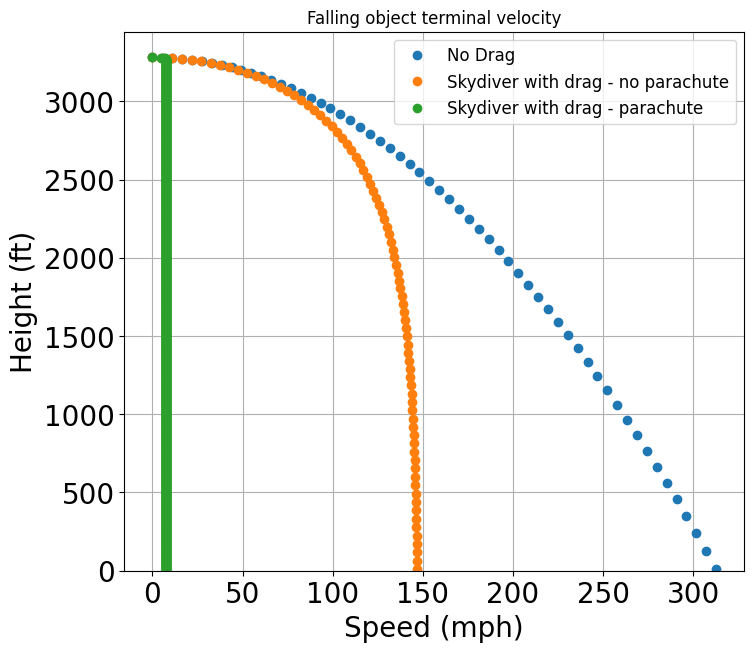

In [48]:
# Plot no drag trajectory
plt.figure(figsize=(8,7))

convert_mps_to_mph = 2.23694
convert_m_to_ft    = 3.28084

ah0_vy  = np.array(h0_vy  , float)
ah1_vy  = np.array(h1_vy  , float)
ah2_vy  = np.array(h2_vy  , float)
ah0_y  = np.array(h0_y  , float)
ah1_y  = np.array(h1_y  , float)
ah2_y  = np.array(h2_y  , float)

speed_0 = np.abs(ah0_vy) * convert_mps_to_mph
speed_1 = np.abs(ah1_vy) * convert_mps_to_mph
speed_2 = np.abs(ah2_vy) * convert_mps_to_mph

height_0 = ah0_y * convert_m_to_ft
height_1 = ah1_y * convert_m_to_ft
height_2 = ah2_y * convert_m_to_ft

print(speed_1)

plt.plot( speed_0, height_0, "o" , label='No Drag')
plt.plot( speed_1, height_1, "o" , label='Skydiver with drag - no parachute')   # label=r'text' -> raw string for latex use
plt.plot( speed_2, height_2, "o" , label='Skydiver with drag - parachute')   # label=r'text' -> raw string for latex use
plt.ylim(0.0)
#plt.axis('square')
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.title('Falling object terminal velocity')
plt.xlabel("Speed (mph)" , fontsize=20)
plt.ylabel("Height (ft)" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.savefig('TerminalVelocity_VYvsY.png', dpi=100)
plt.show()

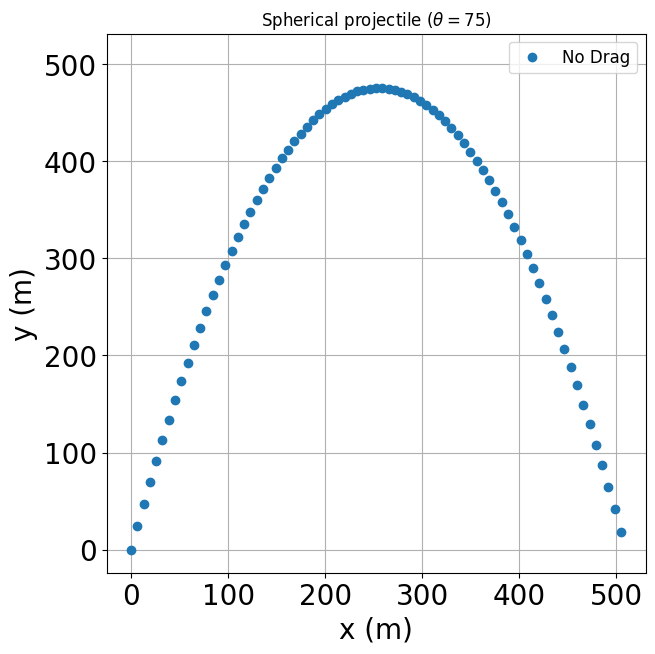

In [49]:
# Plot no drag trajectory
plt.figure(figsize=(8,7))
plt.plot(b0_x, b0_y, "o" , label='No Drag')   # label=r'text' -> raw string for latex use
plt.ylim(0.0)
plt.axis('square')
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.title(r'Spherical projectile ($\theta='+str(temp_theta)+'$)')
plt.xlabel("x (m)" , fontsize=20)
plt.ylabel("y (m)" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
plt.savefig('NoDrag_YvsX.png', dpi=100)
plt.show()

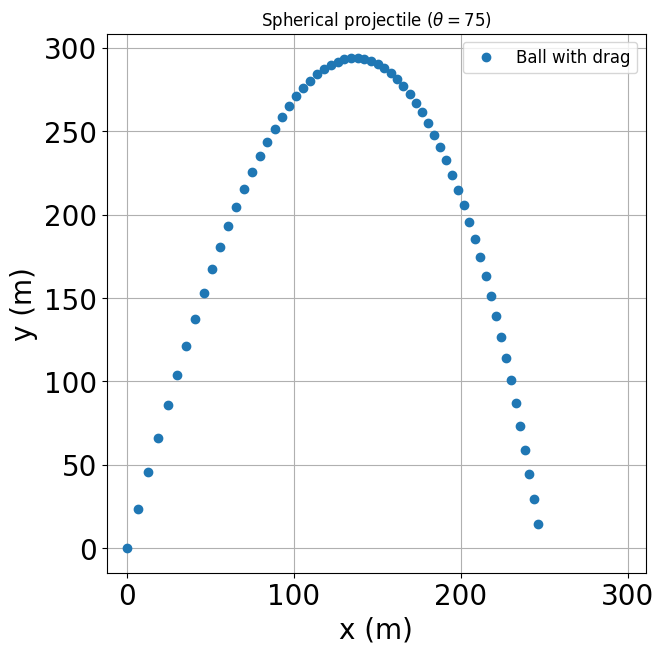

In [50]:
plt.figure(figsize=(8,7))
plt.plot(b4_x, b4_y, "o" , label='Ball with drag')   # label=r'text' -> raw string for latex use
plt.ylim(0.0)
plt.axis('square')
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.title(r'Spherical projectile ($\theta='+str(temp_theta)+'$)')
plt.xlabel("x (m)" , fontsize=20)
plt.ylabel("y (m)" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
#plt.savefig('figs/Drag_YvsX.png', dpi=100)
plt.show()

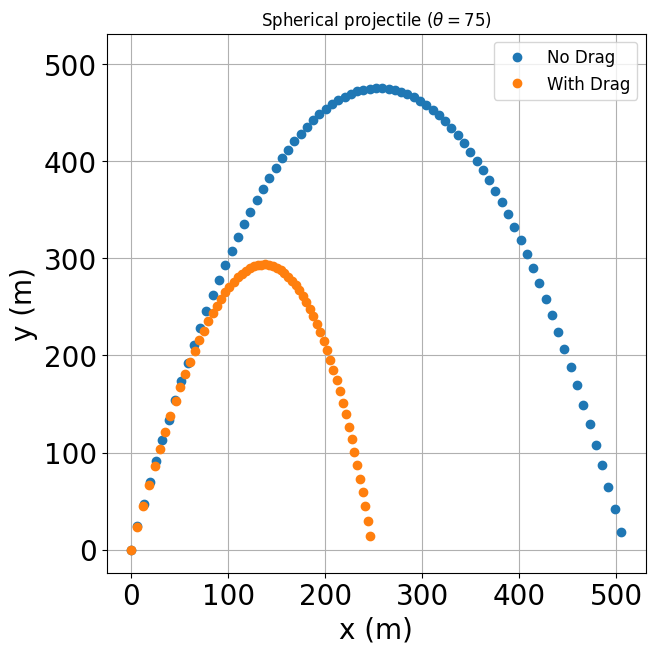

In [51]:
plt.figure(figsize=(8,7))
plt.plot(b0_x, b0_y, "o" , label='No Drag')   # label=r'text' -> raw string for latex use
plt.plot(b4_x, b4_y, "o" , label='With Drag') # label=r'text' -> raw string for latex use
plt.ylim(0.0)
plt.axis('square')
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.title(r'Spherical projectile ($\theta='+str(temp_theta)+'$)')
plt.xlabel("x (m)" , fontsize=20)
plt.ylabel("y (m)" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
#plt.savefig('figs/CompareDragNoDrag_YvsX.png', dpi=100)
plt.show()

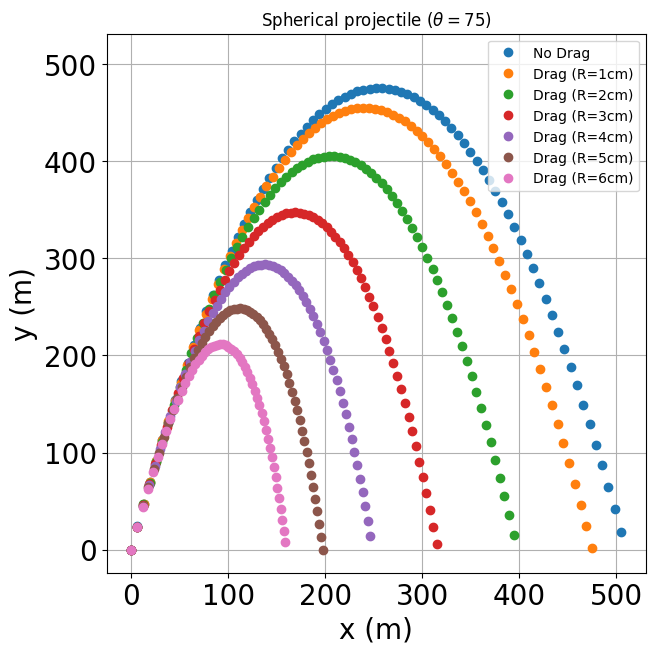

In [52]:
plt.figure(figsize=(8,7))
plt.plot(b0_x, b0_y, "o" , label='No Drag')   # label=r'text' -> raw string for latex use
plt.plot(b1_x, b1_y, "o" , label='Drag (R=1cm)')   # label=r'text' -> raw string for latex use
plt.plot(b2_x, b2_y, "o" , label='Drag (R=2cm)') # label=r'text' -> raw string for latex use
plt.plot(b3_x, b3_y, "o" , label='Drag (R=3cm)') # label=r'text' -> raw string for latex use
plt.plot(b4_x, b4_y, "o" , label='Drag (R=4cm)') # label=r'text' -> raw string for latex use
plt.plot(b5_x, b5_y, "o" , label='Drag (R=5cm)') # label=r'text' -> raw string for latex use
plt.plot(b6_x, b6_y, "o" , label='Drag (R=6cm)') # label=r'text' -> raw string for latex use
plt.ylim(0.0)
plt.axis('square')
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.title(r'Spherical projectile ($\theta='+str(temp_theta)+'$)')
plt.xlabel("x (m)" , fontsize=20)
plt.ylabel("y (m)" , fontsize=20)
plt.legend(loc='upper right', fontsize=10)
#plt.savefig('figs/CompareDragNoDrag_VaryBallSize_YvsX.png', dpi=100)
plt.show()

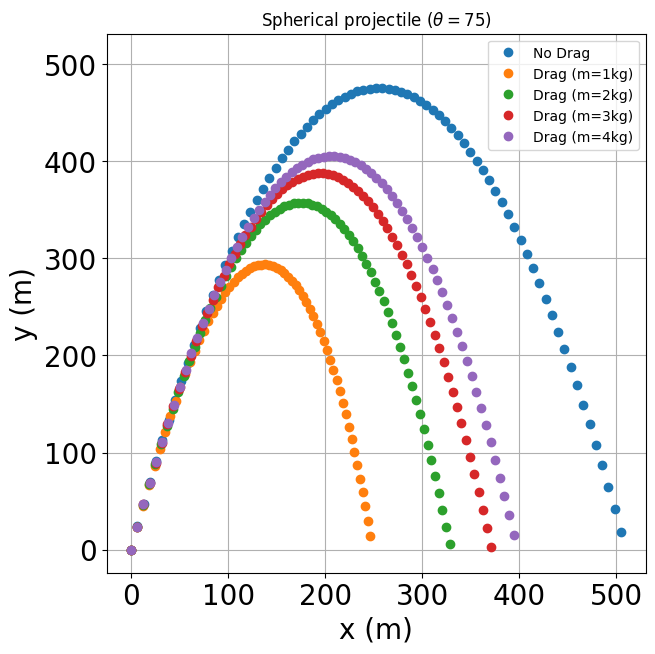

In [53]:
plt.figure(figsize=(8,7))
plt.plot(b0_x, b0_y, "o" , label='No Drag')   # label=r'text' -> raw string for latex use
plt.plot(c1_x, c1_y, "o" , label='Drag (m=1kg)')   # label=r'text' -> raw string for latex use
plt.plot(c2_x, c2_y, "o" , label='Drag (m=2kg)') # label=r'text' -> raw string for latex use
plt.plot(c3_x, c3_y, "o" , label='Drag (m=3kg)') # label=r'text' -> raw string for latex use
plt.plot(c4_x, c4_y, "o" , label='Drag (m=4kg)') # label=r'text' -> raw string for latex use
plt.ylim(0.0)
plt.axis('square')
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.title(r'Spherical projectile ($\theta='+str(temp_theta)+'$)')
plt.xlabel("x (m)" , fontsize=20)
plt.ylabel("y (m)" , fontsize=20)
plt.legend(loc='upper right', fontsize=10)
#plt.savefig('figs/CompareDragNoDrag_VaryMass_YvsX.png', dpi=100)
plt.show()

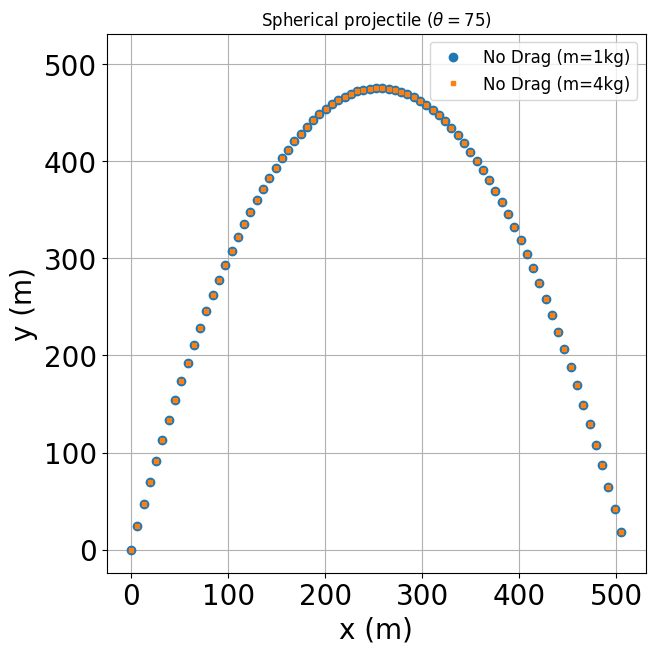

In [54]:
# Plot no drag trajectory
plt.figure(figsize=(8,7))
plt.plot(b0_x, b0_y, "o" , label='No Drag (m=1kg)')   # label=r'text' -> raw string for latex use
plt.plot(c0_x, c0_y, "s" , markersize=3, label='No Drag (m=4kg)')   # label=r'text' -> raw string for latex use
plt.ylim(0.0)
plt.axis('square')
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.title(r'Spherical projectile ($\theta='+str(temp_theta)+'$)')
plt.xlabel("x (m)" , fontsize=20)
plt.ylabel("y (m)" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
#plt.savefig('figs/NoDrag_VaryMass_YvsX.png', dpi=100)
plt.show()

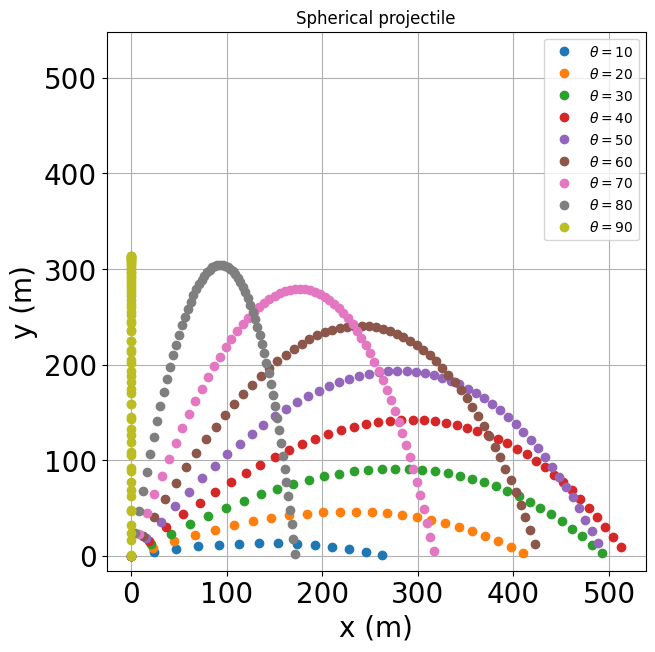

In [55]:
plt.figure(figsize=(8,7))
#plt.plot(b0_x, b0_y, "o" , label='No Drag')   # label=r'text' -> raw string for latex use
plt.plot(d1_x, d1_y, "o" , label=r'$\theta = 10$')   # label=r'text' -> raw string for latex use
plt.plot(d2_x, d2_y, "o" , label=r'$\theta = 20$') # label=r'text' -> raw string for latex use
plt.plot(d3_x, d3_y, "o" , label=r'$\theta = 30$') # label=r'text' -> raw string for latex use
plt.plot(d4_x, d4_y, "o" , label=r'$\theta = 40$') # label=r'text' -> raw string for latex use
plt.plot(d5_x, d5_y, "o" , label=r'$\theta = 50$') # label=r'text' -> raw string for latex use
plt.plot(d6_x, d6_y, "o" , label=r'$\theta = 60$') # label=r'text' -> raw string for latex use
plt.plot(d7_x, d7_y, "o" , label=r'$\theta = 70$') # label=r'text' -> raw string for latex use
plt.plot(d8_x, d8_y, "o" , label=r'$\theta = 80$') # label=r'text' -> raw string for latex use
plt.plot(d9_x, d9_y, "o" , label=r'$\theta = 90$') # label=r'text' -> raw string for latex use
plt.ylim(0.0)
plt.axis('square')
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.title(r'Spherical projectile')
plt.xlabel("x (m)" , fontsize=20)
plt.ylabel("y (m)" , fontsize=20)
plt.legend(loc='upper right', fontsize=10)
#plt.savefig('figs/Drag_VaryLaunchAngle_YvsX.png', dpi=100)
plt.show()

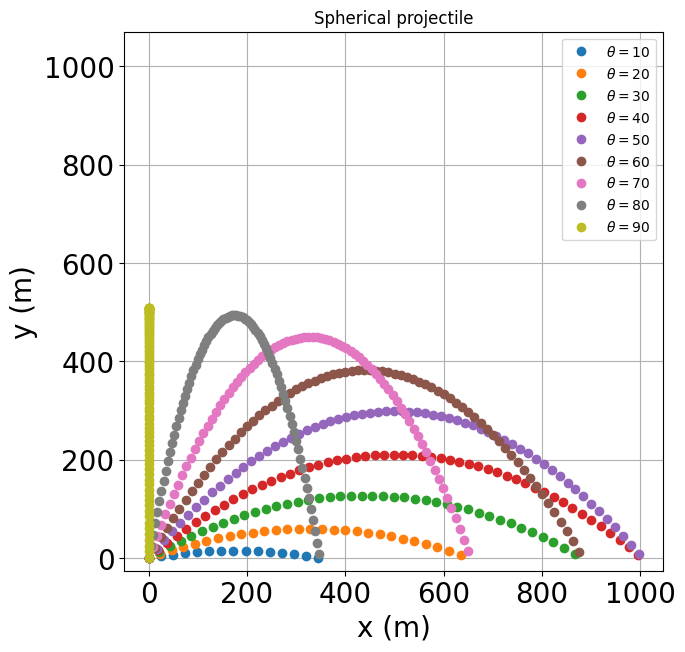

In [56]:
plt.figure(figsize=(8,7))
#plt.plot(b0_x, b0_y, "o" , label='No Drag')   # label=r'text' -> raw string for latex use
plt.plot(e1_x, e1_y, "o" , label=r'$\theta = 10$')   # label=r'text' -> raw string for latex use
plt.plot(e2_x, e2_y, "o" , label=r'$\theta = 20$') # label=r'text' -> raw string for latex use
plt.plot(e3_x, e3_y, "o" , label=r'$\theta = 30$') # label=r'text' -> raw string for latex use
plt.plot(e4_x, e4_y, "o" , label=r'$\theta = 40$') # label=r'text' -> raw string for latex use
plt.plot(e5_x, e5_y, "o" , label=r'$\theta = 50$') # label=r'text' -> raw string for latex use
plt.plot(e6_x, e6_y, "o" , label=r'$\theta = 60$') # label=r'text' -> raw string for latex use
plt.plot(e7_x, e7_y, "o" , label=r'$\theta = 70$') # label=r'text' -> raw string for latex use
plt.plot(e8_x, e8_y, "o" , label=r'$\theta = 80$') # label=r'text' -> raw string for latex use
plt.plot(e9_x, e9_y, "o" , label=r'$\theta = 90$') # label=r'text' -> raw string for latex use
plt.ylim(0.0)
plt.axis('square')
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.title(r'Spherical projectile')
plt.xlabel("x (m)" , fontsize=20)
plt.ylabel("y (m)" , fontsize=20)
plt.legend(loc='upper right', fontsize=10)
#plt.savefig('figs/NoDrag_VaryLaunchAngle_YvsX.png', dpi=100)
plt.show()

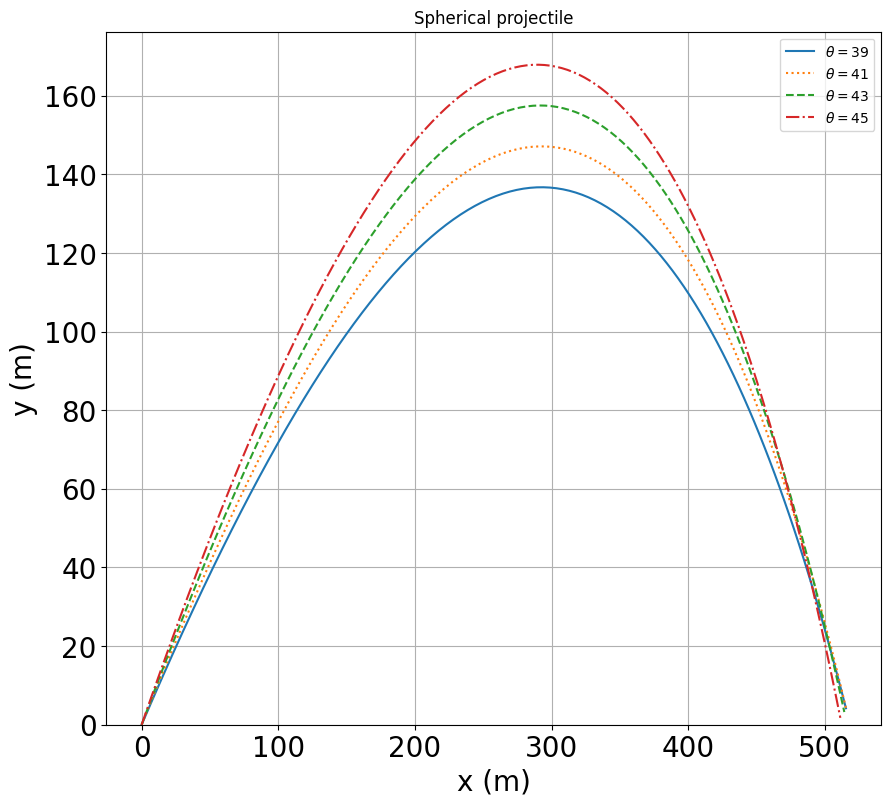

In [57]:
plt.figure(figsize=(10,9))
#plt.plot(b0_x, b0_y, "o" , label='No Drag')   # label=r'text' -> raw string for latex use
#plt.plot(f1_x, f1_y,  "-",  label=r'$\theta = 38$')   # label=r'text' -> raw string for latex use
plt.plot(f2_x, f2_y,   "-", label=r'$\theta = 39$') # label=r'text' -> raw string for latex use
#plt.plot(f3_x, f3_y,  "-",  label=r'$\theta = 40$') # label=r'text' -> raw string for latex use
plt.plot(f4_x, f4_y,   ":", label=r'$\theta = 41$') # label=r'text' -> raw string for latex use
#plt.plot(f5_x, f5_y,  "-",  label=r'$\theta = 42$') # label=r'text' -> raw string for latex use
plt.plot(f6_x, f6_y,   "--", label=r'$\theta = 43$') # label=r'text' -> raw string for latex use
#plt.plot(f7_x, f7_y,  "-",  label=r'$\theta = 44$') # label=r'text' -> raw string for latex use
plt.plot(f8_x, f8_y,   "-.", label=r'$\theta = 45$') # label=r'text' -> raw string for latex use
#plt.plot(f9_x, f9_y,  "-",  label=r'$\theta = 46$') # label=r'text' -> raw string for latex use
plt.ylim(0.0)
#plt.axis('square')
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.title(r'Spherical projectile')
plt.xlabel("x (m)" , fontsize=20)
plt.ylabel("y (m)" , fontsize=20)
plt.legend(loc='upper right', fontsize=10)
#plt.savefig('figs/Drag_VaryLaunchAngle_YvsX.png', dpi=100)
plt.show()

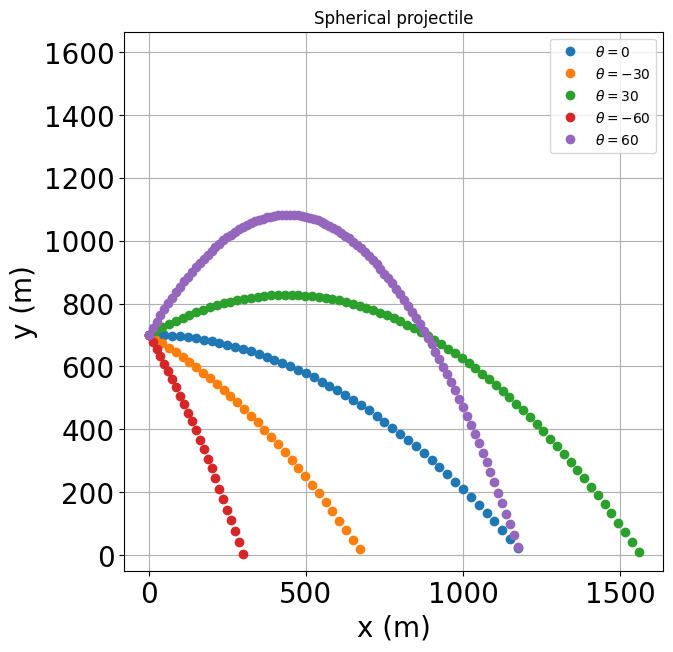

In [58]:
plt.figure(figsize=(8,7))
#plt.plot(b0_x, b0_y, "o" , label='No Drag')   # label=r'text' -> raw string for latex use
#plt.plot(g1_x, g1_y, "o" , label=r'$\theta = 10$')   # label=r'text' -> raw string for latex use
#plt.plot(g2_x, g2_y, "o" , label=r'$\theta = 20$') # label=r'text' -> raw string for latex use
#plt.plot(g3_x, g3_y, "o" , label=r'$\theta = 30$') # label=r'text' -> raw string for latex use
plt.plot(g0_x, g0_y, "o" , label=r'$\theta =   0$') # label=r'text' -> raw string for latex use
plt.plot(g3_x, g3_y, "o" , label=r'$\theta = -30$') # label=r'text' -> raw string for latex use
plt.plot(g4_x, g4_y, "o" , label=r'$\theta = 30$') # label=r'text' -> raw string for latex use
plt.plot(g5_x, g5_y, "o" , label=r'$\theta = -60$') # label=r'text' -> raw string for latex use
plt.plot(g6_x, g6_y, "o" , label=r'$\theta = 60$') # label=r'text' -> raw string for latex use
plt.ylim(0.0)
plt.axis('square')
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.title(r'Spherical projectile')
plt.xlabel("x (m)" , fontsize=20)
plt.ylabel("y (m)" , fontsize=20)
plt.legend(loc='upper right', fontsize=10)
#plt.savefig('figs/NoDrag_VaryLaunchAngle_YvsX.png', dpi=100)
plt.show()

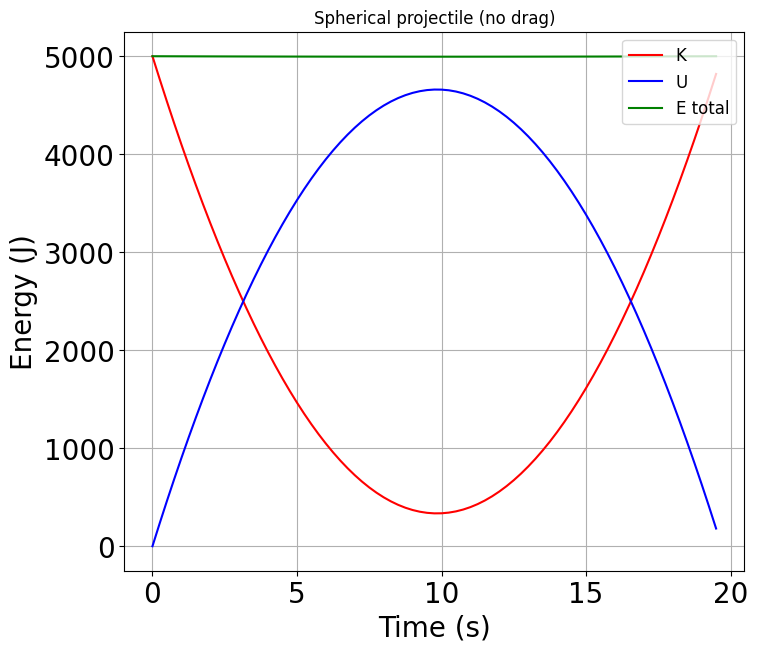

In [59]:
### Calculate Energies
a0_x  = np.array(b0_x  , float)
a0_y  = np.array(b0_y  , float)
a0_vx = np.array(b0_vx , float)
a0_vy = np.array(b0_vy , float)
a0_t  = np.array(b0_t  , float)

a0_v_squared = a0_vx*a0_vx+a0_vy*a0_vy
a0_K         =  0.5 * m * a0_v_squared
a0_U         =  9.8 * m * a0_y
a0_T         = a0_K + a0_U

plt.figure(figsize=(8,7))
plt.plot(a0_t, a0_K, "r" , label=r'K') # label=r'text' -> raw string for latex use
plt.plot(a0_t, a0_U, "b" , label=r'U') # label=r'text' -> raw string for latex use
plt.plot(a0_t, a0_T, "g" , label=r'E total') # label=r'text' -> raw string for latex use
#plt.ylim(0.0)
#plt.axis('square')
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.title('Spherical projectile (no drag)')
plt.xlabel("Time (s)" , fontsize=20)
plt.ylabel("Energy (J)" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
#plt.savefig('figs/NoDrag_EvsT.png', dpi=100)
plt.show()


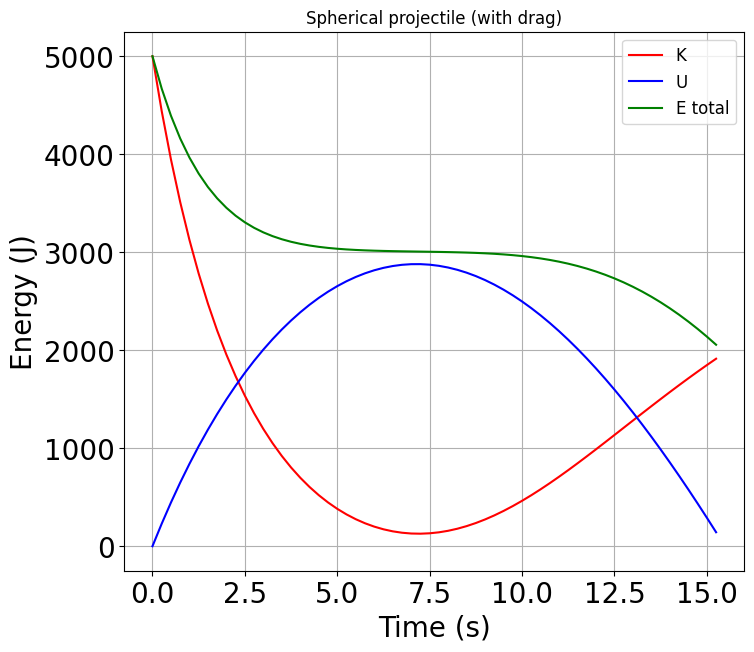

In [60]:
### Calculate Energies
a4_x  = np.array(b4_x  , float)
a4_y  = np.array(b4_y  , float)
a4_vx = np.array(b4_vx , float)
a4_vy = np.array(b4_vy , float)
a4_t  = np.array(b4_t  , float)

a4_v_squared = a4_vx*a4_vx+a4_vy*a4_vy
a4_K         =  0.5 * m * a4_v_squared
a4_U         =  9.8 * m * a4_y
a4_T         = a4_K + a4_U

plt.figure(figsize=(8,7))
plt.plot(a4_t, a4_K, "r" , label=r'K') # label=r'text' -> raw string for latex use
plt.plot(a4_t, a4_U, "b" , label=r'U') # label=r'text' -> raw string for latex use
plt.plot(a4_t, a4_T, "g" , label=r'E total') # label=r'text' -> raw string for latex use
#plt.ylim(0.0)
#plt.axis('square')
plt.tick_params(axis='both', which='major', labelsize=20)
plt.grid(True)
plt.title('Spherical projectile (with drag)')
plt.xlabel("Time (s)" , fontsize=20)
plt.ylabel("Energy (J)" , fontsize=20)
plt.legend(loc='upper right', fontsize=12)
#plt.savefig('figs/Drag_EvsT.png', dpi=100)
plt.show()


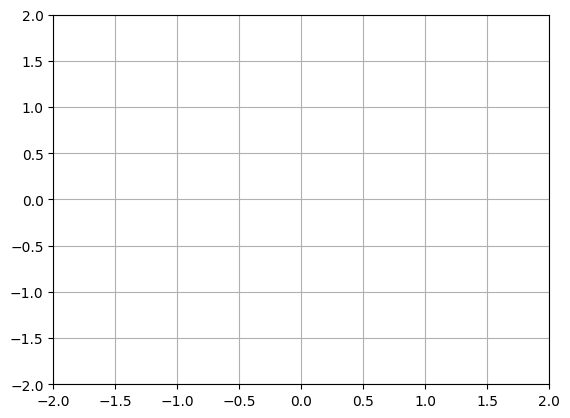

In [ ]:
#https://matplotlib.org/examples/animation/double_pendulum_animated.html

"""
===========================
The double pendulum problem
===========================

This animation illustrates the double pendulum problem.
"""

# Double pendulum formula translated from the C code at
# http://www.physics.usyd.edu.au/~wheat/dpend_html/solve_dpend.c

from numpy import sin, cos
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
import matplotlib.animation as animation

G = 9.8  # acceleration due to gravity, in m/s^2
L1 = 1.0  # length of pendulum 1 in m
L2 = 1.0  # length of pendulum 2 in m
M1 = 1.0  # mass of pendulum 1 in kg
M2 = 1.0  # mass of pendulum 2 in kg


def derivs(state, t):

    dydx = np.zeros_like(state)
    dydx[0] = state[1]

    del_ = state[2] - state[0]
    den1 = (M1 + M2)*L1 - M2*L1*cos(del_)*cos(del_)
    dydx[1] = (M2*L1*state[1]*state[1]*sin(del_)*cos(del_) +
               M2*G*sin(state[2])*cos(del_) +
               M2*L2*state[3]*state[3]*sin(del_) -
               (M1 + M2)*G*sin(state[0]))/den1

    dydx[2] = state[3]

    den2 = (L2/L1)*den1
    dydx[3] = (-M2*L2*state[3]*state[3]*sin(del_)*cos(del_) +
               (M1 + M2)*G*sin(state[0])*cos(del_) -
               (M1 + M2)*L1*state[1]*state[1]*sin(del_) -
               (M1 + M2)*G*sin(state[2]))/den2

    return dydx

# create a time array from 0..100 sampled at 0.05 second steps
dt = 0.05
t = np.arange(0.0, 20, dt)

# th1 and th2 are the initial angles (degrees)
# w10 and w20 are the initial angular velocities (degrees per second)
th1 = 120.0
w1 = 0.0
th2 = -10.0
w2 = 0.0

# initial state
state = np.radians([th1, w1, th2, w2])

# integrate your ODE using scipy.integrate.
y = integrate.odeint(derivs, state, t)

x1 = L1*sin(y[:, 0])
y1 = -L1*cos(y[:, 0])

x2 = L2*sin(y[:, 2]) + x1
y2 = -L2*cos(y[:, 2]) + y1

fig = plt.figure()
ax = fig.add_subplot(111, autoscale_on=False, xlim=(-2, 2), ylim=(-2, 2))
ax.grid()

line, = ax.plot([], [], 'o-', lw=2)
time_template = 'time = %.1fs'
time_text = ax.text(0.05, 0.9, '', transform=ax.transAxes)


def init():
    line.set_data([], [])
    time_text.set_text('')
    return line, time_text


def animate(i):
    thisx = [0, x1[i], x2[i]]
    thisy = [0, y1[i], y2[i]]

    line.set_data(thisx, thisy)
    time_text.set_text(time_template % (i*dt))
    return line, time_text

ani = animation.FuncAnimation(fig, animate, np.arange(1, len(y)),
                              interval=25, blit=True, init_func=init)

# ani.save('double_pendulum.mp4', fps=15)
plt.show()

#ani.save('the_movie.mp4', writer = 'mencoder', fps=15)

from IPython.display import HTML
HTML(ani.to_html5_video())

## Boundary Value Problems

All of the examples so far have been initial value problems (IVPs). For IVPs we know all the initial conditions and we march forward in time using the rules of physics.

**Boundary Value Problems (BVPs)** are different. With BVPs you typically have less information about the inital state (for example, you may know about the initial position of a projectile but not the initial angle). Instead you have some information about the final state (for example, the final position). This is a fundamentally different problem. Instead of using numerical methods to guess where a projectile will land, now we know where the projectile will land and have to figure out the path it must take to get there.

Other example BVPs are steady state problems where there is no time dependence. For example, if you know the temperature of both ends of a rod, you can figure out what the temperature must be at every interior point within the rod.



### BVP Example - Cannonball

Let's use a cannonball as our first example. Let's say we know the initial launch position (x=0, y=0) and a fixed launch speed (e.g., $v_0 = 100$ m/s), but we don't know the launch angle $\theta$. We do know that there is a castle 500 meters away that we want to hit. We want our cannonball to land at the target position ($x=500, y=0$).

Our initial state is not completely known (we're missing the angle, which means we're missing $v_x(0)$ and $v_y(0)$). The problem is defined by conditions at two different points (the launch at $x=0$ and the landing at $x=500$), making this a **Boundary Value Problem (BVP)**.

The BVP is to find the full path of the projectile that hits this target. The trick to solving this is to turn this into an IVP. We simply guess the missing parameter (angle), use an IVP solver to figure out where the projectile lands, and then repeat. It turns out we can do this intelligently by using a root finder to optimize our guessing. This method is known as the **Shooting Method**.

Shooting Method:

1. Refraim - We can't solve this BVP directly. Instead, we'll create a new, simpler problem: "Find the value of the launch angle $\theta$ that makes the cannonball land at $x=500$."
2.  Guess - Let's guess a launch angle, say $\theta = 45^\circ$.
3.  Shoot - Now we have a complete **Initial Value Problem**!
    * $x(0) = 0$
    * $y(0) = 0$
    * $v_x(0) = v_0 \cos(45^\circ)$
    * $v_y(0) = v_0 \sin(45^\circ)$
    We can now use our `rk4` solver to run a full simulation and find the entire trajectory.
4.  Check the error - The simulation runs until the cannonball hits the ground ($y \le 0$). Let's say it lands at $x_{solution} = 480$ meters. Our guess was wrong. We can define an `Error` function:
    `Error(angle) = x_solution(angle) - x_target`
    `Error(45°) = 480 - 500 = -20` meters. (We undershot).
5.  Automate the Guessing - We could "guess and check" by hand (try $\theta=50^\circ$, shoot again, check error...), but this is slow. A smarter way is to use a **root-finder**. We have a function `Error(angle)`, and we want to find the `angle` that makes `Error(angle) = 0`.
    * A simple root finder like the bisection method is much faster than a guess and check method.
        * Start with a bracket you know works: [20, 70]. You know Error(20) is positive and Error(70) is negative.
        * Try the exact middle: 45°.
        * Check the error. Let's say Error(45) is positive.
        * You now know the real answer isn't between 45° and 70° (since both are positive). The answer must be between 20° and 45°.
        * You just cut your search area in half with one guess.
        * Repeat
    * A root-finder like brentq (Brent's method, named after Richard Brent from 1973) is more advanced but has the same benefits (very fast compared to guess and check). We will use `scipy.optimize.brentq` as our root-finder. It's fast and robust, but it requires an initial "bracket" (a low guess and a high guess) where it can search for the root.
    
    
Here is the full Python code to solve this problem.





--- Solving Projectile BVP ---
Target: 500.0 m, Launch Speed: 125.0 m/s
Scanning the error function...


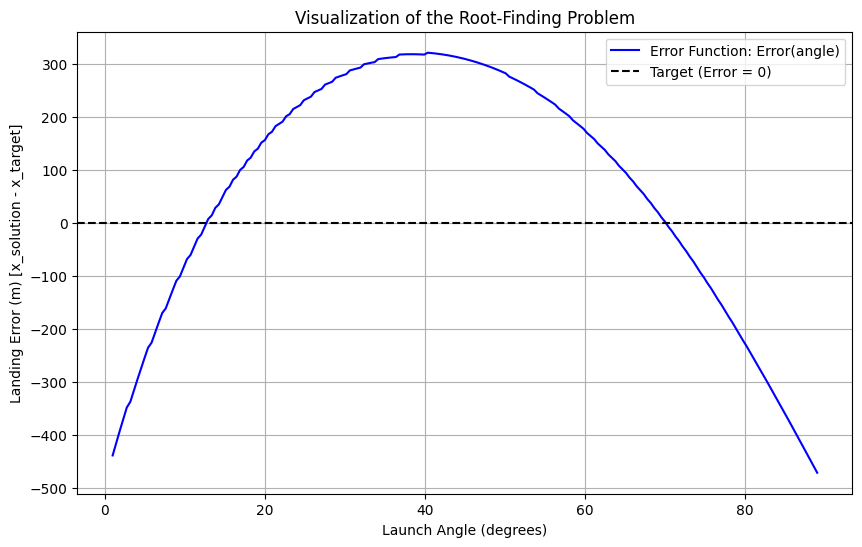


Scanning for roots (sign changes)...
  Found valid bracket: [12.5, 12.9]
  Found valid bracket: [70.0, 70.4]

--- Solution(s) Found! ---
  Solution 1: 12.6388 degrees
  Solution 2: 70.0955 degrees
Plotting all found trajectories...


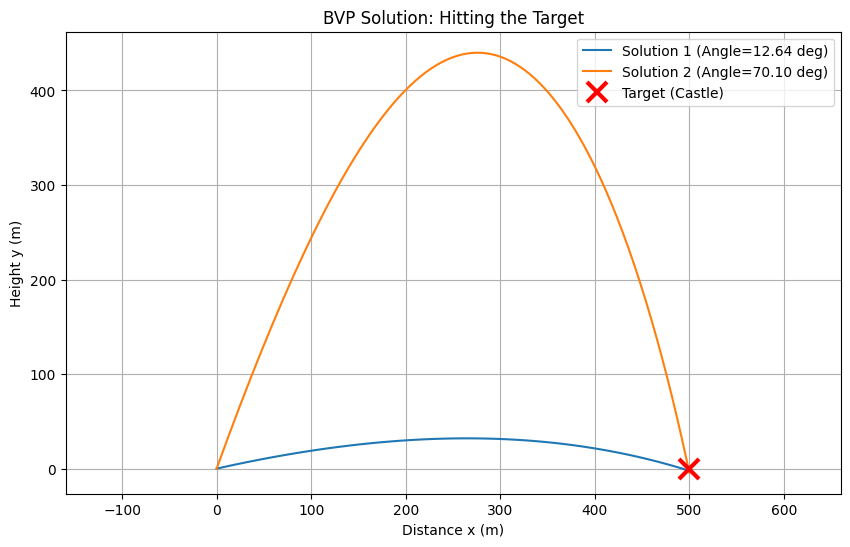

In [62]:
# Cannonball with Drag
#  Flat surface
#  Goal: Find path to hit castle (BVP)
#  Refraimed Goal: Find initial angle to hit castle

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# RK4 Solver
def rk4(model, r, t, dt, model_params):
    """
    Standard RK4 step that passes parameters to the model.
    """
    k1 = dt * model(r, t, model_params)
    k2 = dt * model(r + 0.5 * k1, t + 0.5 * dt, model_params)
    k3 = dt * model(r + 0.5 * k2, t + 0.5 * dt, model_params)
    k4 = dt * model(r + k3, t + dt, model_params)
    return r + (k1 + 2*k2 + 2*k3 + k4) / 6.0

# Projectile with Drag model
def projectile_model(r, t, params):
    """
    Projectile motion with quadratic drag
    r = [x, vx, y, vy]
    r' = [vx, ax, vy, ay]
    """
    # Unpack parameters
    g = params['g']
    m = params['m']
    C_D = params['C_D']
    rho = params['rho']
    A = params['A']

    # Unpack state vector
    x, vx, y, vy = r

    # Calculate speed and drag force
    v = np.sqrt(vx**2 + vy**2)
    F_D = 0.5 * rho * A * C_D * v**2

    # Calculate accelerations
    epsilon = 1e-8  # trick to avoid dividing by zero
    ax = -(F_D / m) * (vx / (v + epsilon))
    ay = -g - (F_D / m) * (vy / (v + epsilon))

    return np.array([vx, ax, vy, ay])

# Objective Function ("Error" Function)
def objective(angle_deg, params, v0, x_target):
    """
    This is the function we want to find the root of.
    It takes a guess (angle_deg) and returns the error.

    Error = x_solution(angle_deg) - x_target
    """

    # BVP Shooter: theta
    # Convert angle to radians
    theta = angle_deg * np.pi / 180.0

    # Set initial conditions for this guess
    vx0 = v0 * np.cos(theta)
    vy0 = v0 * np.sin(theta)

    # Initial state vector: [x, vx, y, vy]
    r = np.array([0.0, vx0, 0.0, vy0])
    t = 0.0
    dt = params['dt']

    # Run the IVP simulation
    while r[2] >= 0.0: # while y >= 0
        r = rk4(projectile_model, r, t, dt, params)
        t += dt

    # Get the final x-position (range)
    x_solution = r[0]

    # Calculate the error
    error = x_solution - x_target
    # print(f"  Guess: {angle_deg:.2f} deg -> Range: {x_solution:.2f} m -> Error: {error:.2f} m")
    return error

#------------------------------------------------------------------------------
# Main BVP Solver

# Define the problem
v0 = 125.0         # m/s (fixed launch speed)
x_target = 500.0   # m (castle distance)

# Simulation parameters
params = {
    'g': 9.8,
    'm': 10.0,       # 10 kg cannonball
    'rho': 1.225,
    'C_D': 0.47,     # Drag of a sphere
    'A': np.pi * 0.1**2, # 10cm radius
    'dt': 0.1
}

print("--- Solving Projectile BVP ---")
print(f"Target: {x_target} m, Launch Speed: {v0} m/s")

# Define a wide, general bracket
angle_low = 1.0
angle_high = 89.0

# For educational reasons (to make a nice plot of the error function)
#   lets do a big brute force scan of many angles and figure out the error
print("Scanning the error function...")
scan_points = 200
angles_scanned = np.linspace(angle_low, angle_high, scan_points)
errors_scanned = []

for angle in angles_scanned:
    errors_scanned.append(objective(angle, params, v0, x_target))

# Plot the Error Function
plt.figure(figsize=(10, 6))
plt.plot(angles_scanned, errors_scanned, 'b-', label='Error Function: Error(angle)')
plt.axhline(0, color='k', linestyle='--', label='Target (Error = 0)')
plt.title('Visualization of the Root-Finding Problem')
plt.xlabel('Launch Angle (degrees)')
plt.ylabel('Landing Error (m) [x_solution - x_target]')
plt.legend()
plt.grid(True)
plt.show()


# brentq needs a guaranteed bracket to work (one negative error, one positive error).
#   In this case there are often two solutions (low and high path for the projectile) which tends to mess up the brackets
#   Lets use our scanned solution to find good brackets for brentq for all possible solutions

print("\nScanning for roots (sign changes)...")
found_roots = []

# Loop through every point in our scanned data, from the first (i=0) up to the second-to-last point.
#   (We stop at len(...) - 1 because we need to compare point 'i' to 'i+1')
for i in range(len(angles_scanned) - 1):

    # Get the error for the current angle and the *next* angle in the scan
    error_current = errors_scanned[i]
    error_next = errors_scanned[i+1]

    # If the two errors have opposite signs (one positive, one negative),
    #  their product must be a negative number.
    if error_current * error_next < 0:

        # A sign change means a root (a zero-crossing) must
        #  exist between these two scanned angles.
        #  This pair of angles forms a "guaranteed-to-work" bracket for brentq.
        small_bracket_low = angles_scanned[i]
        small_bracket_high = angles_scanned[i+1]

        print(f"  Found valid bracket: [{small_bracket_low:.1f}, {small_bracket_high:.1f}]")

        try:
            # Now, we use the "smart" solver (brentq) on this "dumb",
            # tiny, safe bracket. brentq will find the exact
            # angle within this small range that gives Error=0.
            root = brentq(
                objective,          # The function to solve
                small_bracket_low,  # The low end of our safe bracket
                small_bracket_high, # The high end of our safe bracket
                args=(params, v0, x_target) # Pass in the other physics parameters
            )

            # Add the high-precision solution to our list
            found_roots.append(root)

        except ValueError:
            # This should be rare, but in case brentq fails,
            # we print a warning and continue the loop.
            print(f"    brentq failed on bracket [{small_bracket_low}, {small_bracket_high}]")
if not found_roots:
    print("\n--- Solver Failed ---")
    print("No roots found in the scanned range.")
    print("The target is likely unreachable at this speed.")
else:
    print(f"\n--- Solution(s) Found! ---")
    for i, angle in enumerate(found_roots):
        print(f"  Solution {i+1}: {angle:.4f} degrees")

    # Plot all valid trajectories
    print("Plotting all found trajectories...")
    plt.figure(figsize=(10, 6))

    for i, correct_angle in enumerate(found_roots):
        # Run the simulation one last time with the correct angle
        theta = correct_angle * np.pi / 180.0
        vx0 = v0 * np.cos(theta)
        vy0 = v0 * np.sin(theta)
        r = np.array([0.0, vx0, 0.0, vy0])
        t = 0.0
        dt = params['dt']

        # Store the path for plotting
        x_path = []
        y_path = []

        while r[2] >= 0.0:
            x_path.append(r[0])
            y_path.append(r[2])
            r = rk4(projectile_model, r, t, dt, params)
            t += dt

        # Add the last point
        x_path.append(r[0])
        y_path.append(r[2])

        plt.plot(x_path, y_path, '-', label=f'Solution {i+1} (Angle={correct_angle:.2f} deg)')

    plt.plot([x_target], [0], 'rx', markersize=15, markeredgewidth=3, label='Target (Castle)')
    plt.title('BVP Solution: Hitting the Target')
    plt.xlabel('Distance x (m)')
    plt.ylabel('Height y (m)')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

## Example 2: Steady-State Heat Conduction

Now lets consider a 1D rod of length $L=1$m.

* The left end at $x=0$ is held at a hot temperature, $T(0) = 100^\circ\text{C}$.
* The right end at $x=1$ is held at a cool temperature, $T(1) = 20^\circ\text{C}$.

For this example, let's make it more interesting. The rod is *also* losing heat to the ambient air (at $T_{amb} = 25^\circ\text{C}$) along its length. The steady-state (no change in time) equation for this is:

$$\frac{d^2T}{dx^2} = k(T(x) - T_{amb})$$

Our BVP is: Find $T(x)$ given $T(0)=100$ and $T(1)=20$.

This is a second order differential equation BVP, so we use the same trick we used earlier: We turn this into two 1st order differential equations:

1.  $\frac{dT}{dx} = v$
2.  $\frac{dv}{dx} = k(T - T_{amb})$



The **Shooting Method** is now:
1.  We don't know the initial slope of the temperature (the rate of change of the temperature with distance at the left most part of the rod $v(0)=T'(0)$). We only know the initial value, $T(0)=100$.
2.  Guess a value for the initial slope, say $T'(0) = -50$.
3.  Now we have a complete IVP! ($T(0)=100, T'(0)=-50$). We can solve this using `rk4`.
4.  We "shoot" our solution across the rod to $x=1$ and check the temperature we get.
5.  Our solution will almost certainly miss the target $T(1)=20$.
6.  We then adjust our initial guess for $T'(0)$ and shoot again.
7.  This again becomes a **root-finding problem**. We want to find the value of $T'(0)$ (our "shot angle") that makes the error at the end zero.
    * `Error(T'(0)) = T_solution(1) - T_target(1)`

We'll again use `scipy.optimize.brentq` as our root-finder.


--- Running Shooting Method ---
Converged! The correct initial slope is: -173.9982


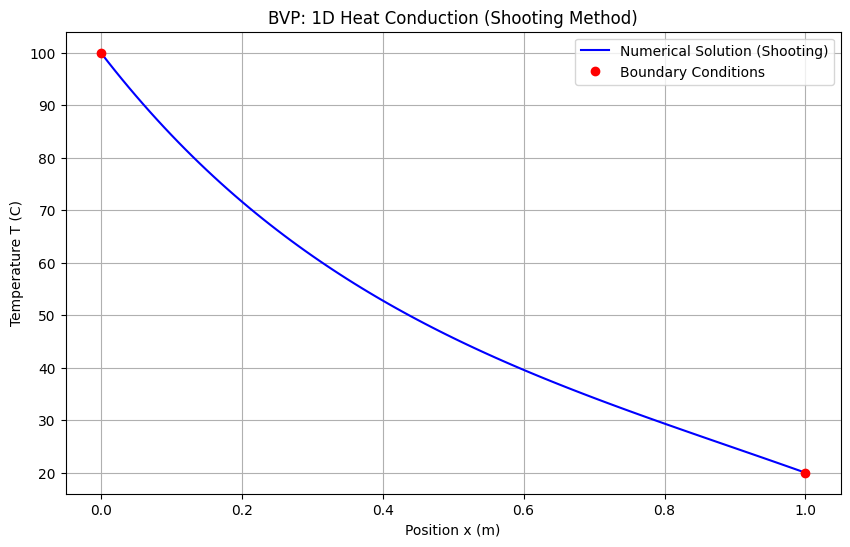

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# RK4 solver
def rk4(model, r, x, dx, params):
    """
    Standard RK4 step that passes parameters.
    model: function(r, x, params)
    r: state vector [T, v]
    x: independent variable (position)
    dx: step size
    """
    k1 = dx * model(r, x, params)
    k2 = dx * model(r + 0.5 * k1, x + 0.5 * dx, params)
    k3 = dx * model(r + 0.5 * k2, x + 0.5 * dx, params)
    k4 = dx * model(r + k3, x + dx, params)
    return r + (k1 + 2*k2 + 2*k3 + k4) / 6.0

# Physics model
def heat_model(r, x, params):
    """
    The model for the 1D heat equation BVP.
    T'' = k * (T - T_amb)

    We set r = [T, v], where v = T'
    So r' = [T', v'] = [v, k * (T - T_amb)]
    """
    T = r[0]
    v = r[1]
    k = params['k']
    T_amb = params['T_amb']

    # Derivatives
    dT_dx = v
    dv_dx = k * (T - T_amb) # This is our T''

    return np.array([dT_dx, dv_dx])

# Objective function (error function)
def objective(initial_slope, params, T_start, T_end, L):
    """
    This is the function we want to find the root of.
    It takes a guess from the root finder (initial_slope) and returns the error.
    """

    # Set up IVP parameters
    dx = params['dx']

    # Initial state: r = [T, v]
    r = np.array([T_start, initial_slope])
    x = 0.0

    # "Shoot" the solution
    while x < L:
        # Ensure the last step doesn't overshoot
        if x + dx > L:
            dx = L - x

        r = rk4(heat_model, r, x, dx, params)
        x += dx

    # Get the final temperature
    T_final_solution = r[0]

    # The error is the difference from our target
    error = T_final_solution - T_end
    return error

#-------------------------------------------
# --- Set up and Run the BVP Solver ---
T_hot = 100.0   # T(0)
T_cool = 20.0   # T(1)
L = 1.0

# Physics parameters
params = {
    'k': 5.0,         # Heat loss coefficient
    'T_amb': 25.0,    # Ambient air temperature
    'dx': 0.01        # Step size for RK4
}

print("--- Running Shooting Method ---")
# We need to give the root-finder a bracket [a, b]
# where the true slope is. This may take trial and error.
# Let's guess the slope is between -200 and 0.
try:
    correct_slope = brentq(
        objective,
        a=-200.0,
        b=50.0, # Increased upper bound just in case
        args=(params, T_hot, T_cool, L)
    )

    print(f"Converged! The correct initial slope is: {correct_slope:.4f}")

    # --- Now, get the final solution ---
    # Run the simulation one last time with the correct slope
    x_points = np.arange(0, L + params['dx'], params['dx'])
    T_solution = []

    r = np.array([T_hot, correct_slope])

    for x in x_points:
        T_solution.append(r[0])
        # Use a consistent dx for the loop
        r = rk4(heat_model, r, x, params['dx'], params)

    plt.figure(figsize=(10, 6))
    plt.plot(x_points, T_solution, 'b-', label='Numerical Solution (Shooting)')
    plt.plot([0, L], [T_hot, T_cool], 'ro', label='Boundary Conditions')
    plt.xlabel('Position x (m)')
    plt.ylabel('Temperature T (C)')
    plt.title('BVP: 1D Heat Conduction (Shooting Method)')
    plt.legend()
    plt.grid(True)
    plt.show()

except ValueError:
    print("Root-finding failed. The initial bracket may be wrong.")

### Part 2: The "SciPy Tools" Method (solve_bvp)

The shooting method is great, but it can be unstable. scipy.integrate.solve_bvp is a more robust method that solves the problem all at once. `solve_bvp` stands for "Solve Boundary Value Problem." It's a powerful tool from the SciPy library that solves ODEs where you know conditions at the *start* and the *end* of the path, but not all the conditions at the start.

`solve_bvp` is fundamentally more powerful than the shooting method. It is a "Collocation" method, meaning it solves for all locations at once instead guess and check. It takes a guess for the entire path and iteratively adjusts all points on that path until the whole thing converges on the true solution that satisfies both the DiffEQ and the boundary conditions.

Since `solve_bvp` is a different method it needs a different setup. It requires three main pieces:

1.  **A Physics Function: `fun(x, y)`**
    * This function defines the differential equation.
    * It takes the entire x mesh (an array) and the entire guessed path y (a 2D array) and must return the derivatives (like $y'$ and $y''$) for every point on the path at once.

2.  **A Boundary Condition Function: `bc(ya, yb)`**
    * This function defines the error at the start and end of the path.
    * ya is the solution at the start point.
    * yb is the solution at the end point.
    * It must return an array of the errors. For example, to set $T(0)=100$ and $T(1)=20$, it would return [ya[0] - 100, yb[0] - 20].

3.  **An Initial Guess: `x_mesh` and `y_guess`**
    * You provide an array of x-points (`x_mesh`) and a 2D array (`y_guess`) that gives a plausible guess for the entire solution path.
    * A good, simple guess is often a straight line connecting your two boundary points.



--- Running scipy.integrate.solve_bvp ---
   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
       1          1.50e-03       0.00e+00          10              2       
       2          3.72e-04       0.00e+00          12              0       
Solved in 2 iterations, number of nodes 12. 
Maximum relative residual: 3.72e-04 
Maximum boundary residual: 0.00e+00


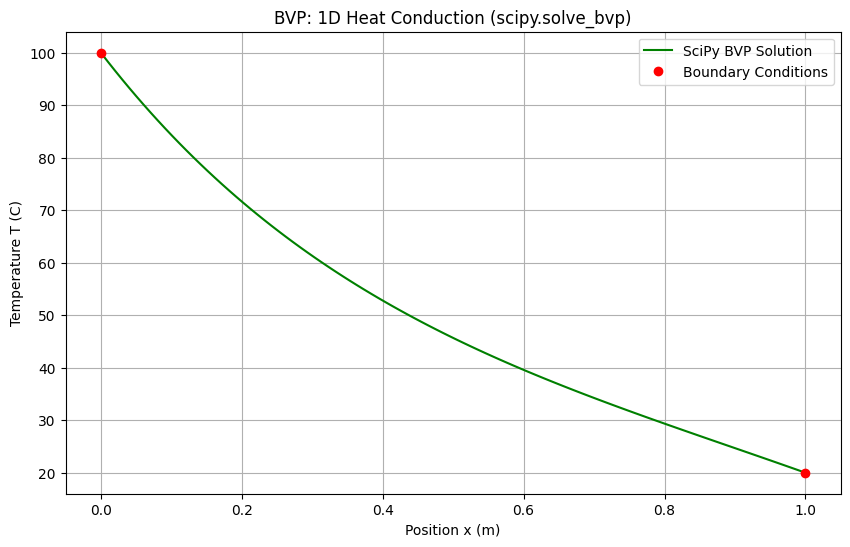

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp

# Define the DiffEQ model
# This is the same physics as our earlier example, but in solve_bvp's required format
#     x is an array of all x positions.
#     y is a 2d state vector array.
#         y[0] is an array of temperature values at each mesh point.
#         y[1] is an array of all the v (slope, $T'$) values at each mesh point.
def heat_model_scipy(x, y):
    """
    y[0] = T
    y[1] = v = T'

    Returns [T', v']
    """
    k = 5.0
    T_amb = 25.0

    # T' = v
    dydx_0 = y[1] # v for every mesh point
    # v' = T'' = k * (T - T_amb)
    dydx_1 = k * (y[0] - T_amb) # dvdx for every mesh point

    # solve_bvp expects us to return an array with the same shape as what we passed to it (y)
    #  vstack helps us return an array of shape (2,N)
    #   by taking two 1D arrays of derivatives (dydx_0 and dydx_1) and stacking them on top of each other. [ [T'_1, T'_2, ...], [v'_1, v'_2, ...] ]
    return np.vstack((dydx_0, dydx_1))

# Define the Boundary Conditions
def heat_bc(ya, yb):
    """
    ya = [T(0), v(0)]
    yb = [T(1), v(1)]

    We want to enforce:
    1. T(0) = 100  ->  ya[0] - 100 = 0
    2. T(1) = 20   ->  yb[0] - 20  = 0
    """
    T_hot = 100.0
    T_cool = 20.0

    err_a = ya[0] - T_hot  # Error at x=0
    err_b = yb[0] - T_cool # Error at x=1

    return np.array([err_a, err_b])

# --- 3. Set up the initial guess ---
L = 1.0
x_mesh = np.linspace(0, L, 10) # 10 points

# We must provide a guess for y(x) at all 10 points.
# Let's just guess a straight line.
# Guess for T(x)
slope_guess = (T_cool - T_hot) / L # rise over run where rise=Tfinal-Tinitial
y_guess_T = T_hot + slope_guess * x_mesh
# Guess for v(x) = T'(x)
y_guess_v = np.full_like(x_mesh, slope_guess) #full_like creates an array of the same shape as x_mesh but with value slope_guess

# Stack them into the correct shape (2, N)
y_guess = np.vstack((y_guess_T, y_guess_v))

print("\n--- Running scipy.integrate.solve_bvp ---")

# --- 4. Run the solver! ---
sol = solve_bvp(heat_model_scipy, heat_bc, x_mesh, y_guess, verbose=2)

# --- 5. Plot the result ---
if sol.success:
    # sol.x are the final mesh points
    # sol.y[0] is the final T(x) solution
    x_plot = np.linspace(0, L, 100)
    y_plot = sol.sol(x_plot)[0] # sol.sol() is an interpolating function

    plt.figure(figsize=(10, 6))
    plt.plot(x_plot, y_plot, 'g-', label='SciPy BVP Solution')
    plt.plot([0, L], [T_hot, T_cool], 'ro', label='Boundary Conditions')
    plt.xlabel('Position x (m)')
    plt.ylabel('Temperature T (C)')
    plt.title('BVP: 1D Heat Conduction (scipy.solve_bvp)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("SciPy BVP solver failed to converge.")